# 1. Loading

## 1.1. Imports and prep

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import joblib
import seaborn as sns
from scipy import stats
import os
import sys
from loguru import logger
from statsmodels.stats.outliers_influence import variance_inflation_factor
import glob

In [44]:
sys.path.append('..')  # points to the Modelling/ folder

from gam import SklearnGAM

sys.path.append('../..')  # points to the code folder
sys.path.append('/data/cleaning-scripts/')
from config import WINDOW_LENGTH, JANUARY_CLEANING_DATE, JULY_CLEANING_DATE, FOULING_PROXY_VAR_NAME_WITH_UNIT, SPEED_VARIABLE, TARGET_VARIABLE


In [45]:
cleaning_events = [JANUARY_CLEANING_DATE, JULY_CLEANING_DATE]

In [46]:
notebook_dir = os.getcwd()
notebook_parent_dir = os.path.dirname(notebook_dir)
notebook_parent_parent_dir = os.path.dirname(notebook_parent_dir)
train_test_dir = os.path.join(notebook_parent_parent_dir, "data", "train-and-test")
train_test_split_path = os.path.join(train_test_dir, f"train_test_splits_{WINDOW_LENGTH}.npz")

## 1.2. Data

In [47]:
data = np.load(train_test_split_path, allow_pickle=True)
X_columns = data['X_columns']
X_train = pd.DataFrame(data['X_train'], columns=X_columns)
X_test  = pd.DataFrame(data['X_test'],  columns=X_columns)
y_train = data['y_train']
y_test  = data['y_test']

In [48]:
ts = np.load(os.path.join(train_test_dir, f"train_test_timestamps_{WINDOW_LENGTH}.npz"))
train_timestamps = pd.to_datetime(ts["train_timestamps"])
test_timestamps  = pd.to_datetime(ts["test_timestamps"])

## 1.3. Models

In [49]:
model_pipelines_incl_foul = {'ridge_regression': None, 'GAM': None, 'random_forest': None, 'NN': None}
model_pipelines_excl_foul = model_pipelines_incl_foul.copy()

In [50]:
for model in model_pipelines_incl_foul.keys():
    # find the pipeline
    model_pipeline_path = os.path.join(notebook_parent_parent_dir, "outputs", "models", f"{model}_pipeline_incl_fouling_{WINDOW_LENGTH}.joblib")
    model_pipeline = joblib.load(model_pipeline_path)
    
    # add the pipeline to the dict
    model_pipelines_incl_foul[model] = model_pipeline

In [51]:
for model in model_pipelines_excl_foul.keys():
    # find the pipeline
    model_pipeline_path = os.path.join(notebook_parent_parent_dir, "outputs", "models", f"{model}_pipeline_excl_fouling_{WINDOW_LENGTH}.joblib")
    model_pipeline = joblib.load(model_pipeline_path)
    
    # add the pipeline to the dict
    model_pipelines_excl_foul[model] = model_pipeline

# 2. Validity & Robustness Checks

## 2.1. GAM-specific

### 2.1.1. Model Summary

In [52]:
# 1. Extract the raw pyGAM model from our fitted pipeline
gam_pipeline = model_pipelines_incl_foul["GAM"]
gam_model = gam_pipeline.named_steps["model"].gam_model_
gam_model.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     58.4496
Link Function:                     IdentityLink Log Likelihood:                                -83468.6904
Number of Samples:                        11955 AIC:                                           167056.2801
                                                AICc:                                          167056.8843
                                                GCV:                                            68848.2641
                                                Scale:                                            261.2329
                                                Pseudo R-Squared:                                   0.9698
Feature Function                  Lam

C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3057525301.py:4: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_model.summary()


#### 

## 2.2. Random-forest specific

### 2.2.1. Feature importance

Fouling proxy should have a decent importance

In [53]:
def plot_rf_feature_importance(pipeline, title="Random Forest Feature Importances", top_n=None):
    """
    Plot feature importances from a fitted RF pipeline.

    Parameters
    ----------
    pipeline : sklearn Pipeline
        Fitted pipeline with 'preprocessor' (ColumnTransformer) and 'model' (RandomForestRegressor) steps.
    title : str
        Plot title.
    top_n : int or None
        If set, only the top_n features by importance are shown.
    """
    feature_names = pipeline.named_steps["preprocessor"].transformers_[0][2]
    importances = pipeline.named_steps["model"].feature_importances_
    std = np.std(
        [tree.feature_importances_ for tree in pipeline.named_steps["model"].estimators_],
        axis=0,
    )

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances, "std": std})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    if top_n is not None:
        importance_df = importance_df.head(top_n)

    fig, ax = plt.subplots(figsize=(8, max(4, len(importance_df) * 0.4)))
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        xerr=importance_df["std"][::-1],
        color="steelblue",
        ecolor="grey",
        capsize=3,
    )
    ax.set_xlabel("Mean decrease in impurity")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return importance_df

def plot_shap_values(pipeline, X, title="SHAP Feature Importance", top_n=None):
    """
    Compute and plot SHAP values from a fitted RF pipeline.

    Parameters
    ----------
    pipeline : sklearn Pipeline
        Fitted pipeline with 'preprocessor' (ColumnTransformer) and 'model' (RandomForestRegressor) steps.
    X : pd.DataFrame
        Raw (untransformed) input features used for SHAP explanation.
    title : str
        Plot title.
    top_n : int or None
        If set, only the top_n features by mean |SHAP| are shown.

    Returns
    -------
    shap_df : pd.DataFrame
        DataFrame with mean absolute SHAP values per feature, sorted descending.
    """
    feature_names = pipeline.named_steps["preprocessor"].transformers_[0][2]

    # Transform X through the preprocessor only
    X_transformed = pipeline.named_steps["preprocessor"].transform(X)
    X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

    # Build TreeExplainer directly on the RF model
    explainer = shap.TreeExplainer(pipeline.named_steps["model"])
    shap_values = explainer.shap_values(X_transformed_df)

    # Mean absolute SHAP value per feature → single importance score
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_df = (
        pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    if top_n is not None:
        shap_df = shap_df.head(top_n)

    # ── Beeswarm summary plot (shows direction + magnitude) ─────────────────
    shap.summary_plot(
        shap_values,
        X_transformed_df,
        feature_names=feature_names,
        max_display=len(shap_df),
        show=False,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

    # ── Bar plot (mean |SHAP|, mirrors your RF importance style) ────────────
    fig, ax = plt.subplots(figsize=(8, max(4, len(shap_df) * 0.4)))
    ax.barh(
        shap_df["feature"][::-1],
        shap_df["mean_abs_shap"][::-1],
        color="steelblue",
    )
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return shap_df




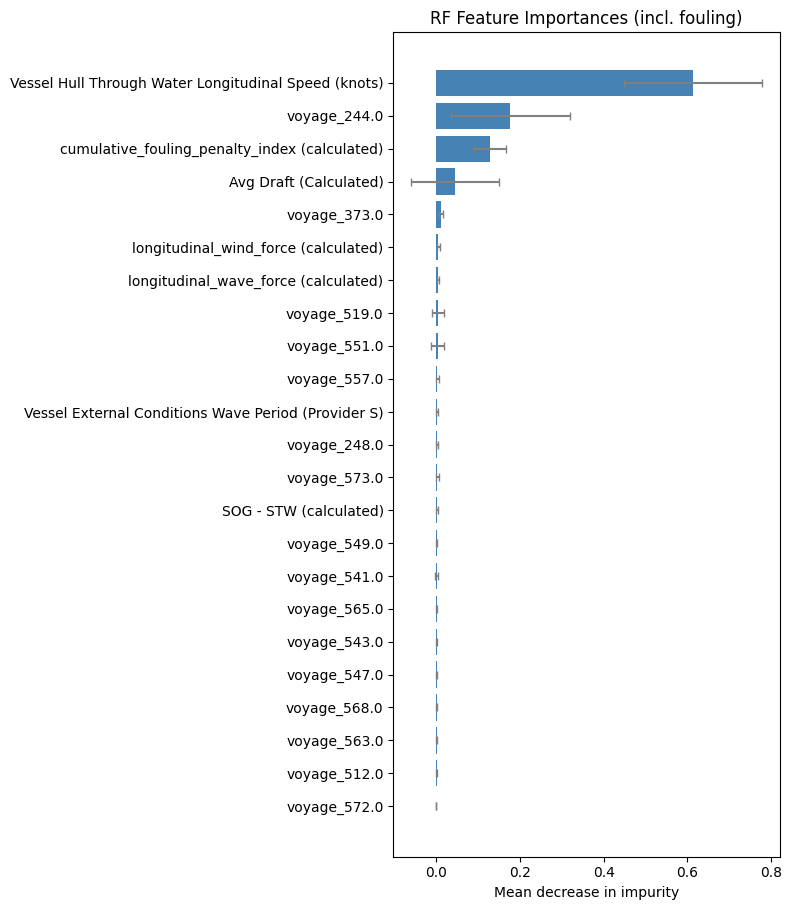

                                             feature  importance      std
Vessel Hull Through Water Longitudinal Speed (knots)    0.614294 0.165129
                                        voyage_244.0    0.176913 0.142958
       cumulative_fouling_penalty_index (calculated)    0.127508 0.038759
                              Avg Draft (Calculated)    0.044311 0.105420
                                        voyage_373.0    0.010590 0.005223
                longitudinal_wind_force (calculated)    0.004475 0.003380
                longitudinal_wave_force (calculated)    0.004467 0.002362
                                        voyage_519.0    0.003902 0.013528
                                        voyage_551.0    0.003221 0.015619
                                        voyage_557.0    0.002207 0.003090
 Vessel External Conditions Wave Period (Provider S)    0.001623 0.001865
                                        voyage_248.0    0.001623 0.002392
                                      

In [54]:
importance_df = plot_rf_feature_importance(
    model_pipelines_incl_foul["random_forest"],
    title="RF Feature Importances (incl. fouling)",
)
print(importance_df.to_string(index=False))

In [55]:
# shap_df = plot_shap_values(model_pipelines_incl_foul["random_forest"],X=X_train,title="SHAP Feature Importance (incl. fouling)")
# print(shap_df.to_string(index=False))

## 2.3. NN-specific

## 2.4. All models

### 2.4.1. Incl. vs. excl fouling performance check

#### Residuals comparison over time, incl with/without fouling

Over time, the residuals for the fouling-free model should have the fouling effect leaking into the error term (residuals increasing over time)

In [56]:
def plot_residuals_with_cleaning_events(
    pipeline_incl_fouling,
    pipeline_excl_fouling,
    X,
    y,
    timestamps,
    cleaning_dates,
    model_name="Model",
    figsize=(16, 5),
):
    """
    Plot residuals over time for two fitted pipelines (incl./excl. fouling features)
    in a 1x2 layout, with vertical lines marking cleaning events.

    Parameters
    ----------
    pipeline_incl_fouling : sklearn-like pipeline
        Fitted pipeline that includes fouling features.
    pipeline_excl_fouling : sklearn-like pipeline
        Fitted pipeline that excludes fouling features.
    X : array-like
        Feature matrix used for prediction.
    y : array-like
        True target values.
    timestamps : array-like
        Datetime-like values aligned with X and y.
    cleaning_dates : array-like
        Datetime-like cleaning event timestamps.
    model_name : str
        Display name for subplot titles.
    figsize : tuple
        Figure size passed to matplotlib.
    """
    y_true = np.asarray(y).reshape(-1)
    time_index = pd.to_datetime(pd.Series(timestamps).reset_index(drop=True))

    if len(time_index) != len(y_true):
        raise ValueError("`timestamps` must have the same length as `y`.")

    pred_incl = np.asarray(pipeline_incl_fouling.predict(X)).reshape(-1)
    pred_excl = np.asarray(pipeline_excl_fouling.predict(X)).reshape(-1)

    if len(pred_incl) != len(y_true) or len(pred_excl) != len(y_true):
        raise ValueError("Predictions and y must have identical lengths.")

    # Sort by time so line plots are chronological
    sort_order = time_index.argsort()
    time_index    = time_index.iloc[sort_order].reset_index(drop=True)
    y_true        = y_true[sort_order]
    pred_incl     = pred_incl[sort_order]
    pred_excl     = pred_excl[sort_order]

    residuals_incl = y_true - pred_incl
    residuals_excl = y_true - pred_excl
    cleaning_dates = pd.to_datetime(cleaning_dates)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    plot_specs = [
        (axes[0], residuals_incl, "Incl. fouling features", "tab:blue"),
        (axes[1], residuals_excl, "Excl. fouling features", "tab:orange"),
    ]

    for ax, residuals, subtitle, color in plot_specs:
        ax.plot(time_index, residuals, color=color, linewidth=0.6, alpha=0.7)
        ax.axhline(0, color="black", linestyle="--", linewidth=1)

        for i, clean_date in enumerate(cleaning_dates):
            label = "Cleaning event" if i == 0 else None
            ax.axvline(clean_date, color="crimson", linestyle=":", linewidth=1.2, alpha=0.85, label=label)

        ax.set_title(f"{model_name}: {subtitle}")
        ax.set_xlabel("Time")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Residual (y - y_hat)")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(loc="upper right")

    fig.suptitle("Residuals Over Time With Cleaning Events")
    fig.tight_layout()
    plt.show()

    return pd.DataFrame(
        {
            "timestamp": time_index,
            "residual_incl_fouling": residuals_incl,
            "residual_excl_fouling": residuals_excl,
        }
    )

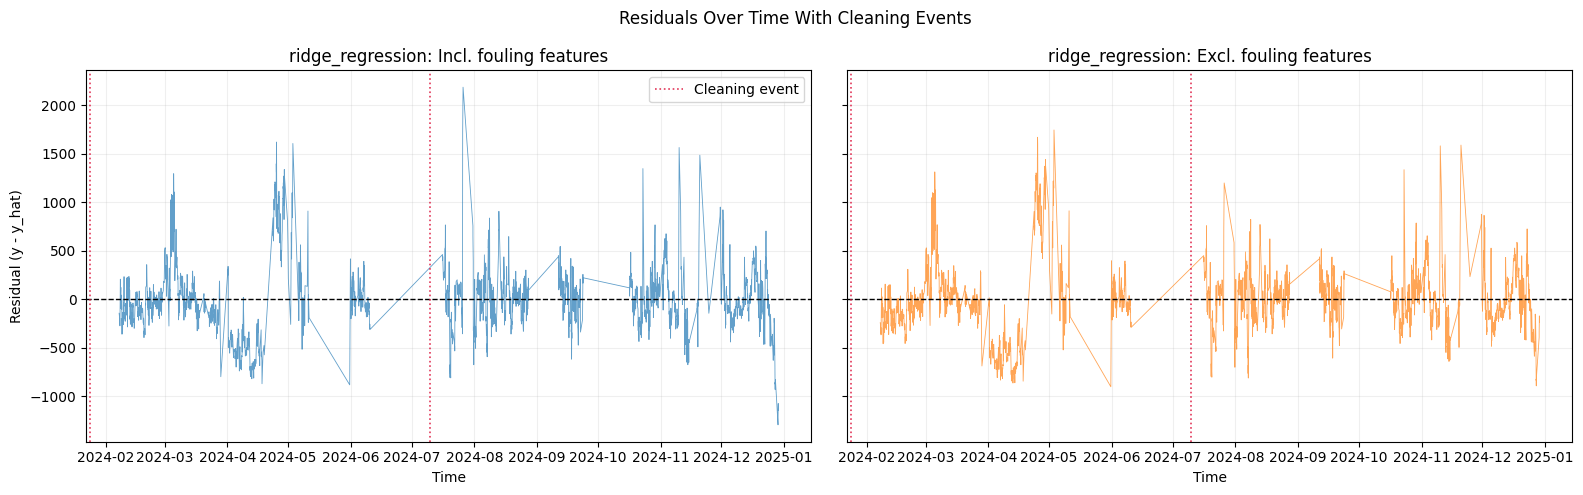

In [57]:
residual_df = plot_residuals_with_cleaning_events(
    model_pipelines_incl_foul["ridge_regression"],
    model_pipelines_excl_foul["ridge_regression"],
    X_test,
    y_test,
    timestamps=test_timestamps,
    cleaning_dates=cleaning_events,
    model_name="ridge_regression",
)

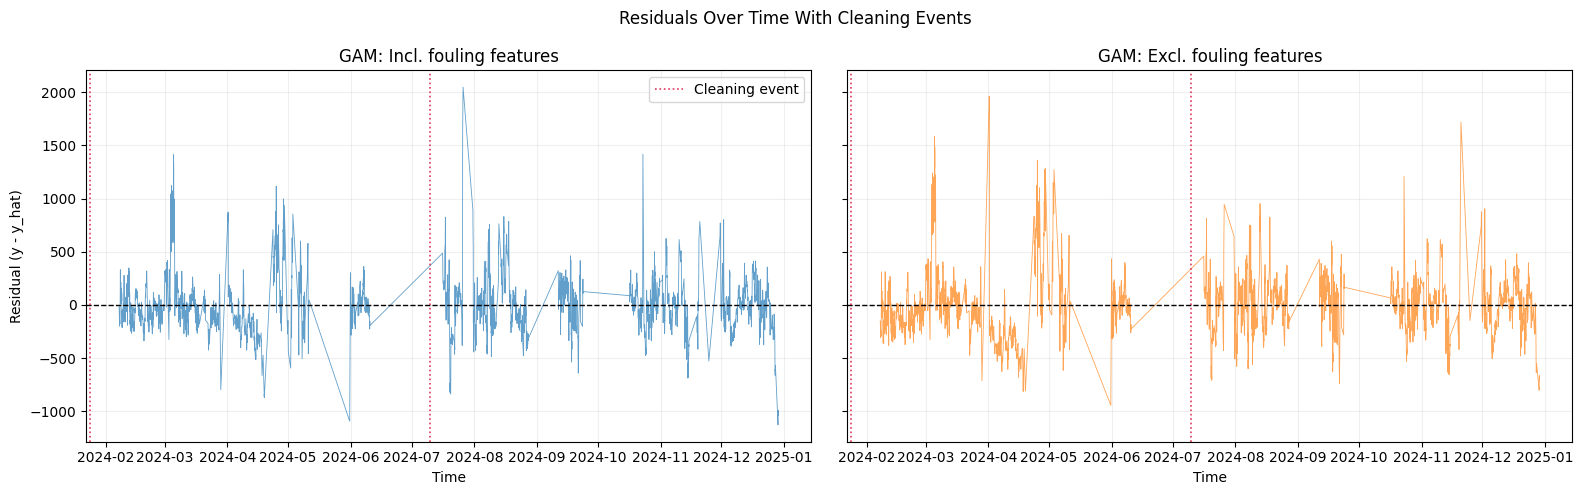

In [58]:
residual_df = plot_residuals_with_cleaning_events(
    model_pipelines_incl_foul["GAM"],
    model_pipelines_excl_foul["GAM"],
    X_test,
    y_test,
    timestamps=test_timestamps,
    cleaning_dates=cleaning_events,
    model_name="GAM",
)

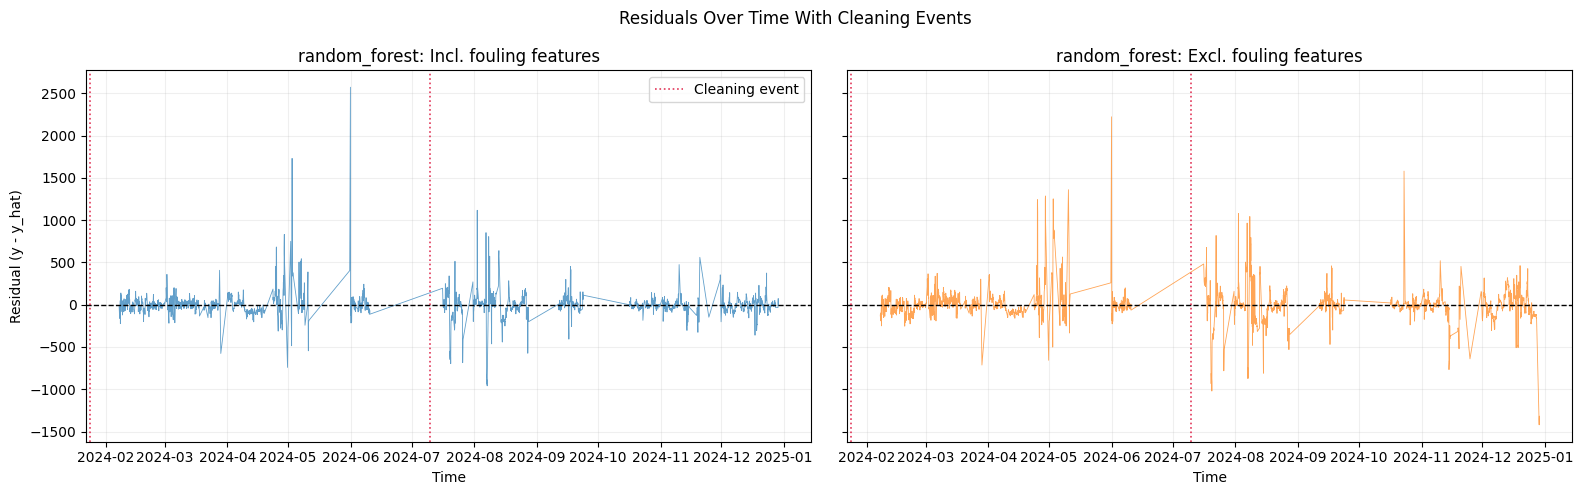

In [59]:
residual_df = plot_residuals_with_cleaning_events(
    model_pipelines_incl_foul["random_forest"],
    model_pipelines_excl_foul["random_forest"],
    X_test,
    y_test,
    timestamps=test_timestamps,
    cleaning_dates=cleaning_events,
    model_name="random_forest",
)

### 2.4.2. Overfitting check

In [60]:
def load_latest_training_results(model_pipelines, outputs_dir):
    """
    For each model in model_pipelines, finds the latest training CSV
    and returns them appended into a single DataFrame.
    """
    dfs = []

    for model in model_pipelines.keys():
        # Find all matching CSVs for this model
        pattern = os.path.join(outputs_dir, f"{model}_training_*.csv")
        files = sorted(glob.glob(pattern))  # alphabetical = chronological for timestamp filenames

        if not files:
            logger.warning(f"No training CSV found for model: {model}")
            continue

        latest_file = files[-1]
        logger.info(f"{model}: loading {os.path.basename(latest_file)}")

        df = pd.read_csv(latest_file)
     #   df.insert(0, "model", model)  # prepend model name for clarity
        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No training CSV files found for any model.")

    return pd.concat(dfs, ignore_index=True)


In [61]:
outputs_dir = os.path.join(notebook_parent_parent_dir, "outputs", "models")
results_df = load_latest_training_results(model_pipelines_incl_foul, outputs_dir)

# Choose only relevant columns 
results_df = results_df[["model", "train_rmse", "test_rmse", "train_mape", "test_mape"]]

display(results_df.style.format({ "train_rmse": "{:.1f}", "test_rmse": "{:.1f}", "train_mape": "{:.4f}", "test_mape": "{:.4f}" }))

2026-03-12 16:25:15.989 | INFO     | __main__:load_latest_training_results:18 - ridge_regression: loading Ridge_Regression_training_20260312_162225.csv
2026-03-12 16:25:15.989 | INFO     | __main__:load_latest_training_results:18 - GAM: loading GAM_training_20260312_162244.csv
2026-03-12 16:25:15.989 | INFO     | __main__:load_latest_training_results:18 - random_forest: loading Random_Forest_training_20260312_162348.csv
2026-03-12 16:25:16.001 | INFO     | __main__:load_latest_training_results:18 - NN: loading NN_training_20260312_162431.csv


,model,train_rmse,test_rmse,train_mape,test_mape
0,Ridge_Regression_incl_fouling,343.1,349.1,0.0665,0.0663
1,Ridge_Regression_excl_fouling,350.6,354.0,0.0674,0.0673
2,GAM_incl_fouling,260.6,271.2,0.0505,0.0512
3,GAM_excl_fouling,291.6,297.7,0.0550,0.0553
4,Random_Forest_incl_fouling,147.5,144.4,0.0199,0.0201
5,Random_Forest_excl_fouling,195.9,197.5,0.0309,0.0310
6,NN_incl_fouling,124.8,127.2,0.0214,0.0218
7,NN_excl_fouling,141.1,144.0,0.0241,0.0249


### 2.4.3. Residual diagnostics

#### Fitted vs. predicted values

In [62]:
def plot_actual_vs_predicted(model_name, pipeline, X, y, figsize=(14, 5)):
    """
    Two side-by-side scatter plots for a fitted pipeline:
      Left  — Actual vs. Predicted  (red diagonal = perfect predictions)
      Right — Residuals vs. Predicted (red horizontal = zero residual)

    Parameters
    ----------
    model_name : str
        Display name used in titles.
    pipeline : sklearn-like pipeline
        Fitted pipeline with a .predict() method.
    X : array-like
        Feature matrix.
    y : array-like
        True target values.
    figsize : tuple
        Figure size.
    """
    y_true = np.asarray(y).reshape(-1)
    y_pred = np.asarray(pipeline.predict(X)).reshape(-1)
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # --- Left: Actual vs. Predicted ---
    ax = axes[0]
    ax.scatter(y_pred, y_true, alpha=0.3, s=8, color="steelblue", rasterized=True)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="red", linewidth=1.2, label="Perfect fit")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{model_name}: Actual vs. Predicted")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.2)

    # --- Right: Residuals vs. Predicted ---
    ax = axes[1]
    ax.scatter(y_pred, residuals, alpha=0.3, s=8, color="tab:orange", rasterized=True)
    ax.axhline(0, color="red", linewidth=1.2, label="Zero residual")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual (y - y_hat)")
    ax.set_title(f"{model_name}: Residuals vs. Predicted")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.2)

    fig.tight_layout()
    plt.show()


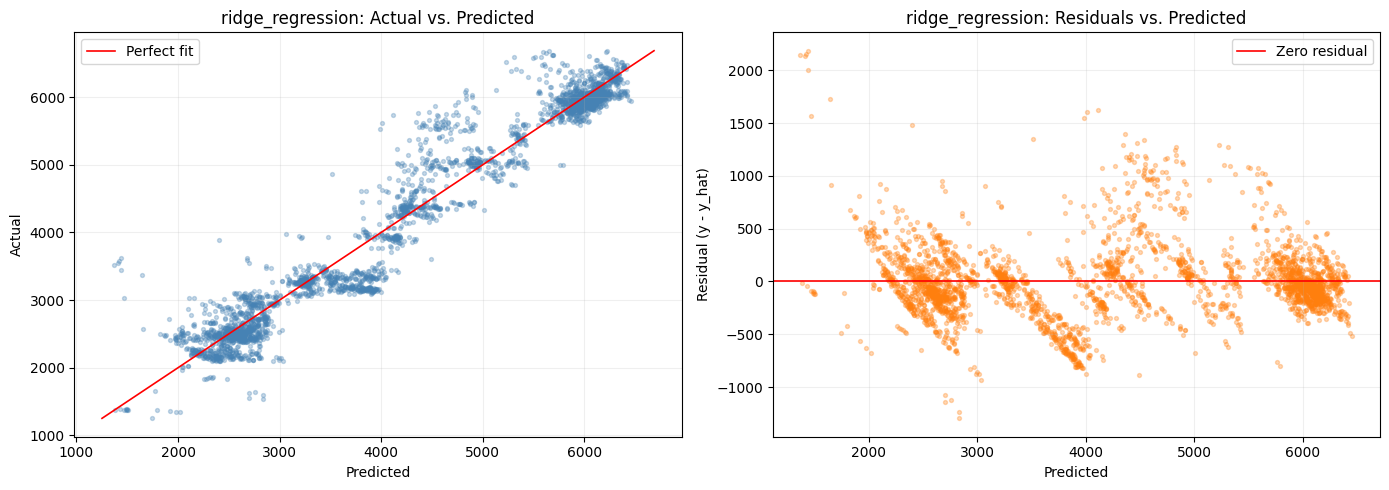

In [63]:
plot_actual_vs_predicted("ridge_regression", model_pipelines_incl_foul["ridge_regression"], X_test, y_test)

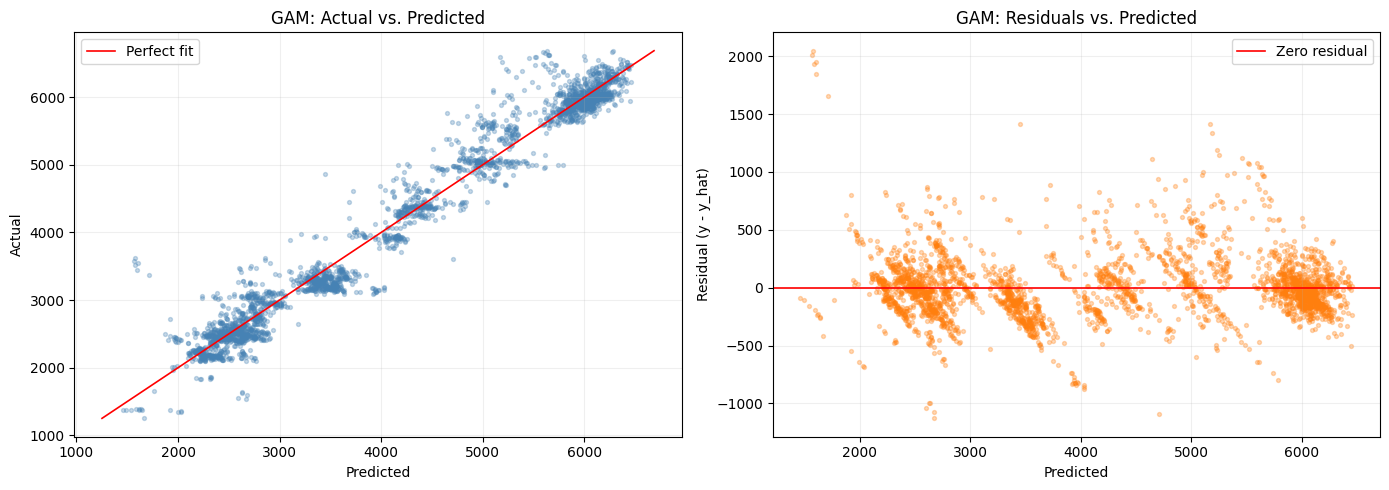

In [64]:
plot_actual_vs_predicted("GAM", model_pipelines_incl_foul["GAM"], X_test, y_test)

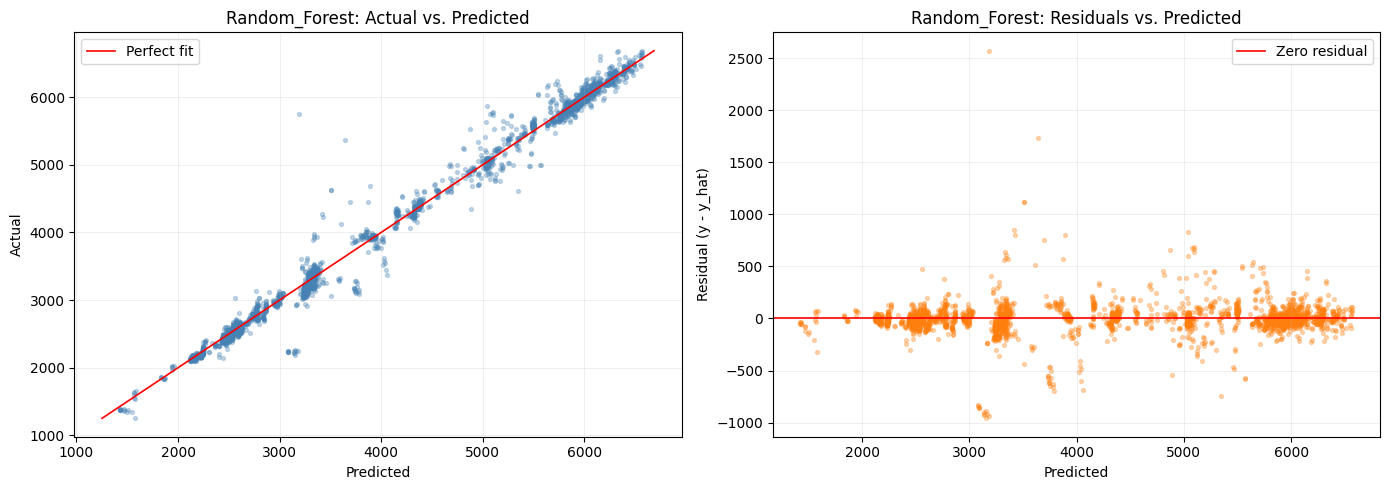

In [65]:
plot_actual_vs_predicted("Random_Forest", model_pipelines_incl_foul["random_forest"], X_test, y_test)

#### QQ plot/normality

In [66]:
def plot_qq(pipelines: dict, X, y, figsize=None):
    """
    QQ plots of residuals for each pipeline in a single side-by-side row.

    Parameters
    ----------
    pipelines : dict
        Mapping of model_name -> fitted pipeline.
    X : array-like
        Feature matrix.
    y : array-like
        True target values.
    figsize : tuple or None
        Figure size. Defaults to (5 * n_models, 5).
    """
    n = len(pipelines)
    if figsize is None:
        figsize = (5 * n, 5)

    y_true = np.asarray(y).reshape(-1)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for ax, (model_name, pipeline) in zip(axes, pipelines.items()):
        residuals = y_true - np.asarray(pipeline.predict(X)).reshape(-1)
        (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist="norm")
        ax.scatter(osm, osr, s=6, alpha=0.4, color="steelblue", rasterized=True)
        ax.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=1.2, label="Normal fit")
        ax.set_title(f"{model_name}: QQ Plot")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Sample quantiles")
        ax.legend(loc="upper left")
        ax.grid(alpha=0.2)

    fig.suptitle("QQ Plots of Residuals")
    fig.tight_layout()
    plt.show()


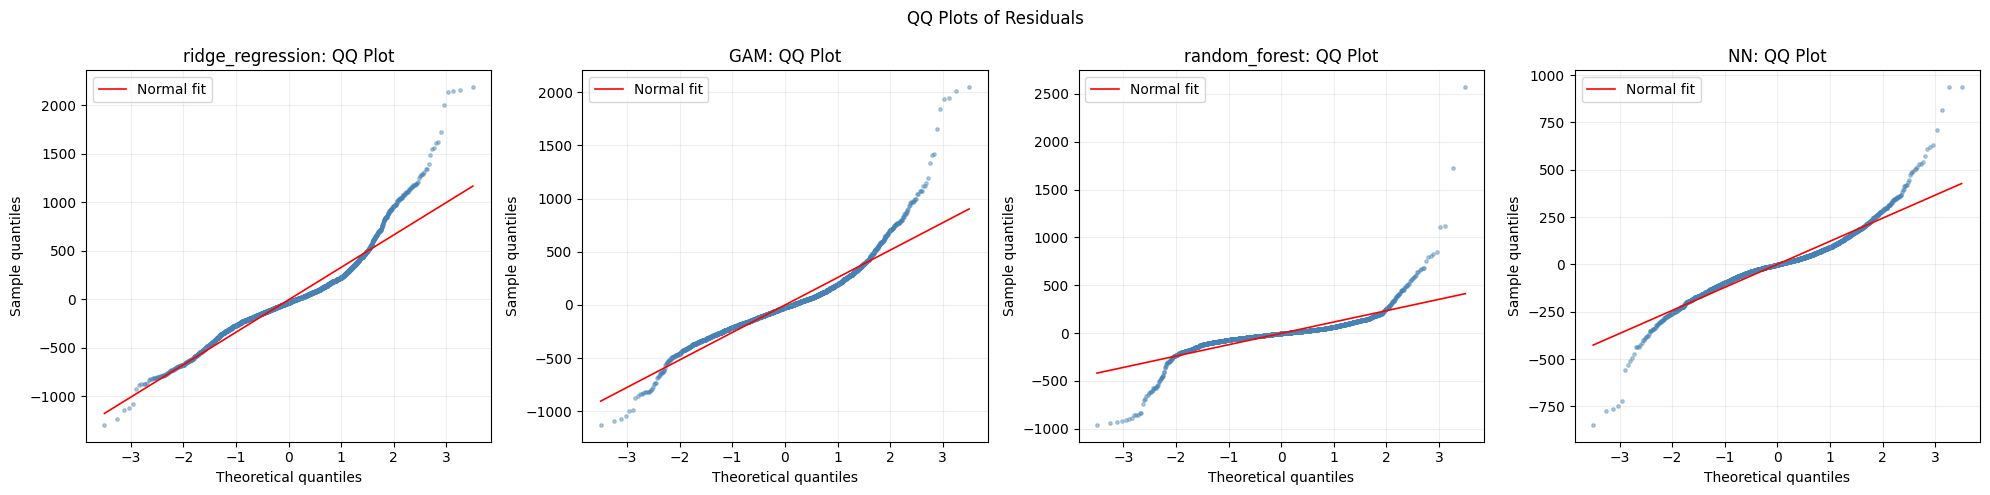

In [67]:
plot_qq(model_pipelines_incl_foul, X_test, y_test)

#### Residual scatter by each feature 

In [68]:
def plot_residuals_by_feature(pipelines: dict, X, y, cols=4, figsize_per_plot=(4, 3)):
    """
    For each model in pipelines, produces a grid of scatter plots (residuals vs. each
    feature) in rows of `cols`. Each model gets its own clearly-titled figure so the
    boundary between models is unambiguous.

    Finally, prints and returns a correlation table: models as rows, features as columns.

    Parameters
    ----------
    pipelines : dict
        Mapping of model_name -> fitted pipeline.
    X : pd.DataFrame
        Feature matrix with named columns.
    y : array-like
        True target values.
    cols : int
        Scatter plots per row (default 4).
    figsize_per_plot : tuple
        (width, height) allocated for each individual subplot.
    """
    X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    feature_names = X_df.columns.tolist()
    y_true = np.asarray(y).reshape(-1)
    n_features = len(feature_names)
    rows = int(np.ceil(n_features / cols))

    corr_records = {}

    for model_name, pipeline in pipelines.items():
        residuals = y_true - np.asarray(pipeline.predict(X_df)).reshape(-1)

        fig, axes = plt.subplots(
            rows, cols,
            figsize=(figsize_per_plot[0] * cols, figsize_per_plot[1] * rows),
        )
        axes_flat = np.array(axes).reshape(-1)

        feature_corrs = {}
        for i, feat in enumerate(feature_names):
            ax = axes_flat[i]
            feat_vals = X_df[feat].values

            # Compute Pearson r; guard against constant features (e.g. all-zero voyage dummies)
            try:
                r = float(np.corrcoef(feat_vals, residuals)[0, 1])
            except (ValueError, AttributeError):
                r = np.nan
            feature_corrs[feat] = r

            ax.scatter(feat_vals, residuals, s=4, alpha=0.25, rasterized=True)
            ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
            r_label = f"{r:.3f}" if not np.isnan(r) else "const"
            ax.set_title(f"{feat}  (r={r_label})", fontsize=8)
            ax.set_xlabel(feat, fontsize=7)
            ax.set_ylabel("Residual", fontsize=7)
            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.2)

        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)

        fig.suptitle(
            f"Residuals vs. Each Feature  —  {model_name}",
            fontsize=13, fontweight="bold",
        )
        fig.tight_layout()
        plt.show()

        corr_records[model_name] = feature_corrs

    # --- Correlation table ---
    corr_df = pd.DataFrame(corr_records).T
    corr_df.index.name = "Model \\ Feature"
    print("\nCorrelation of each feature with model residuals:")
    display(
        corr_df.style
        .format("{:.3f}")
        .background_gradient(cmap="coolwarm", axis=None, vmin=-1, vmax=1)
    )

    return corr_df

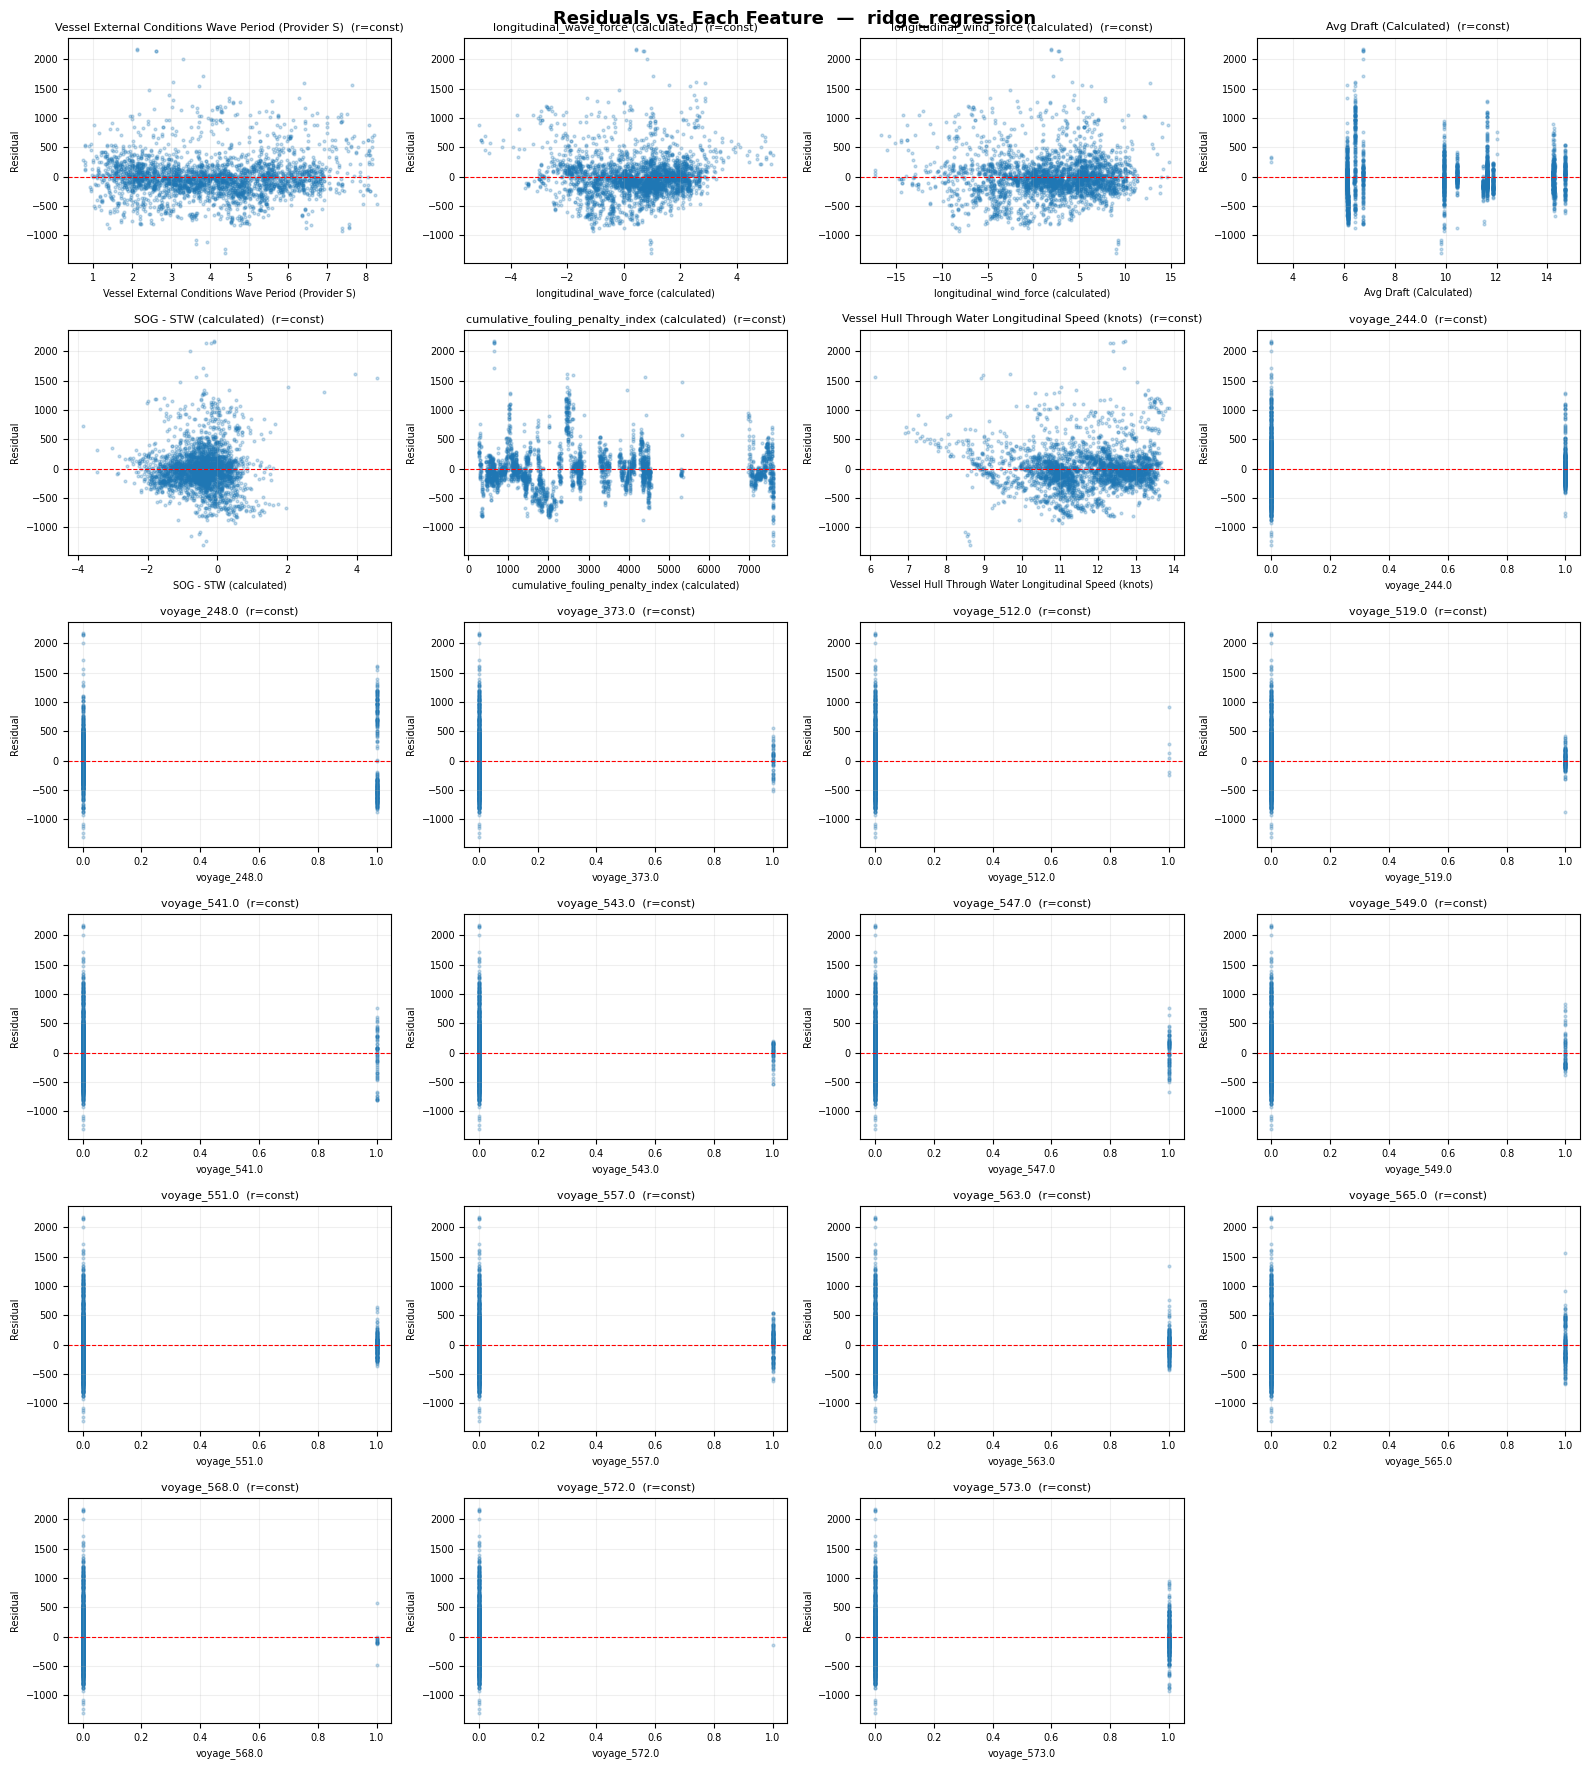

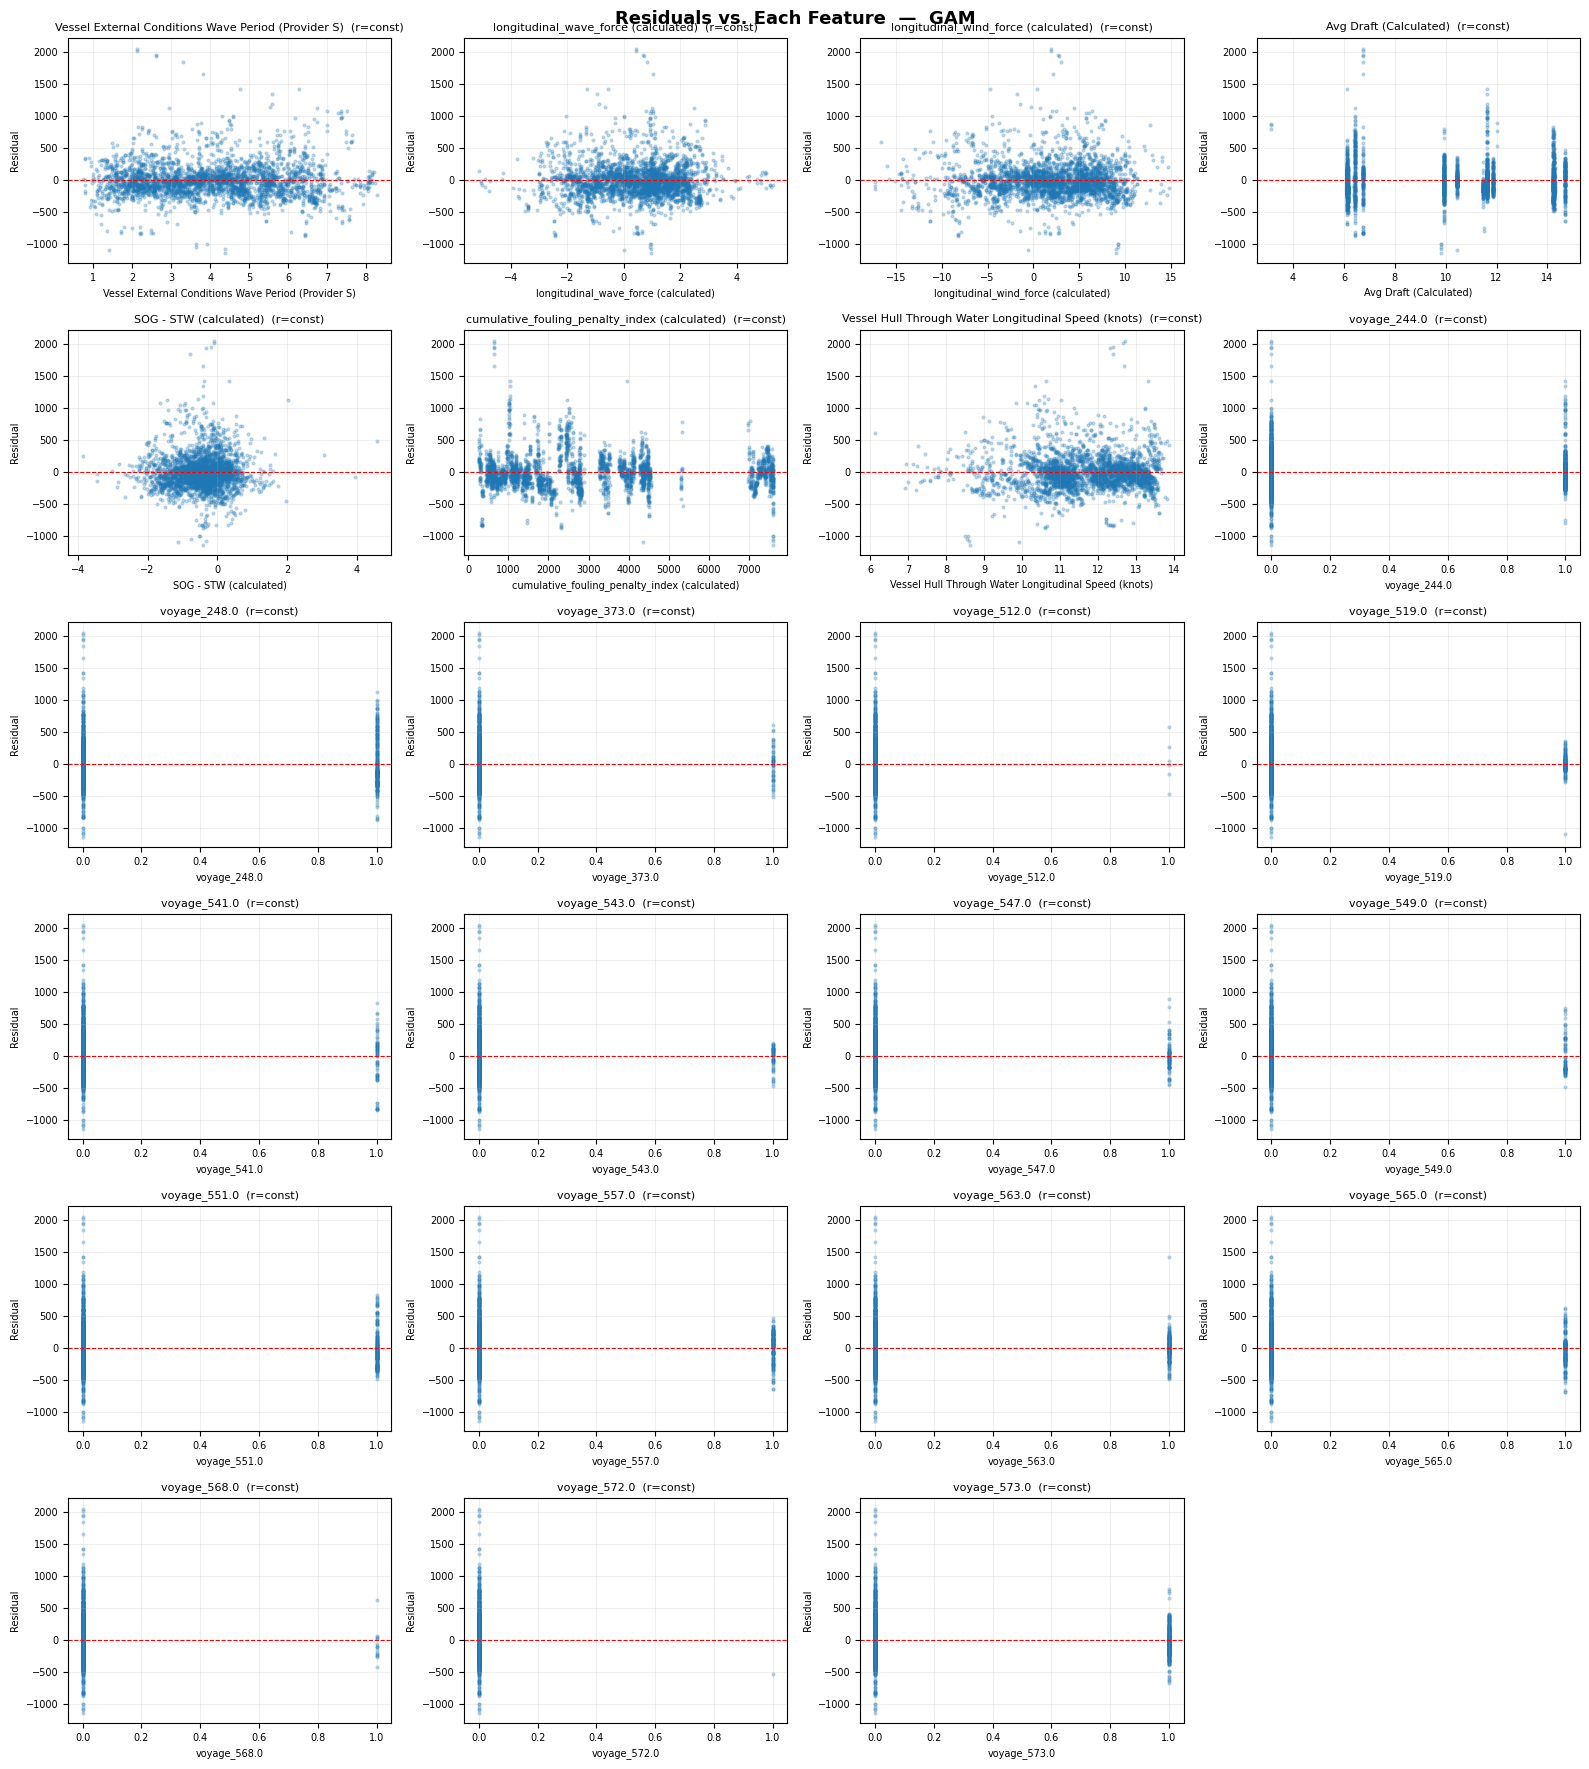

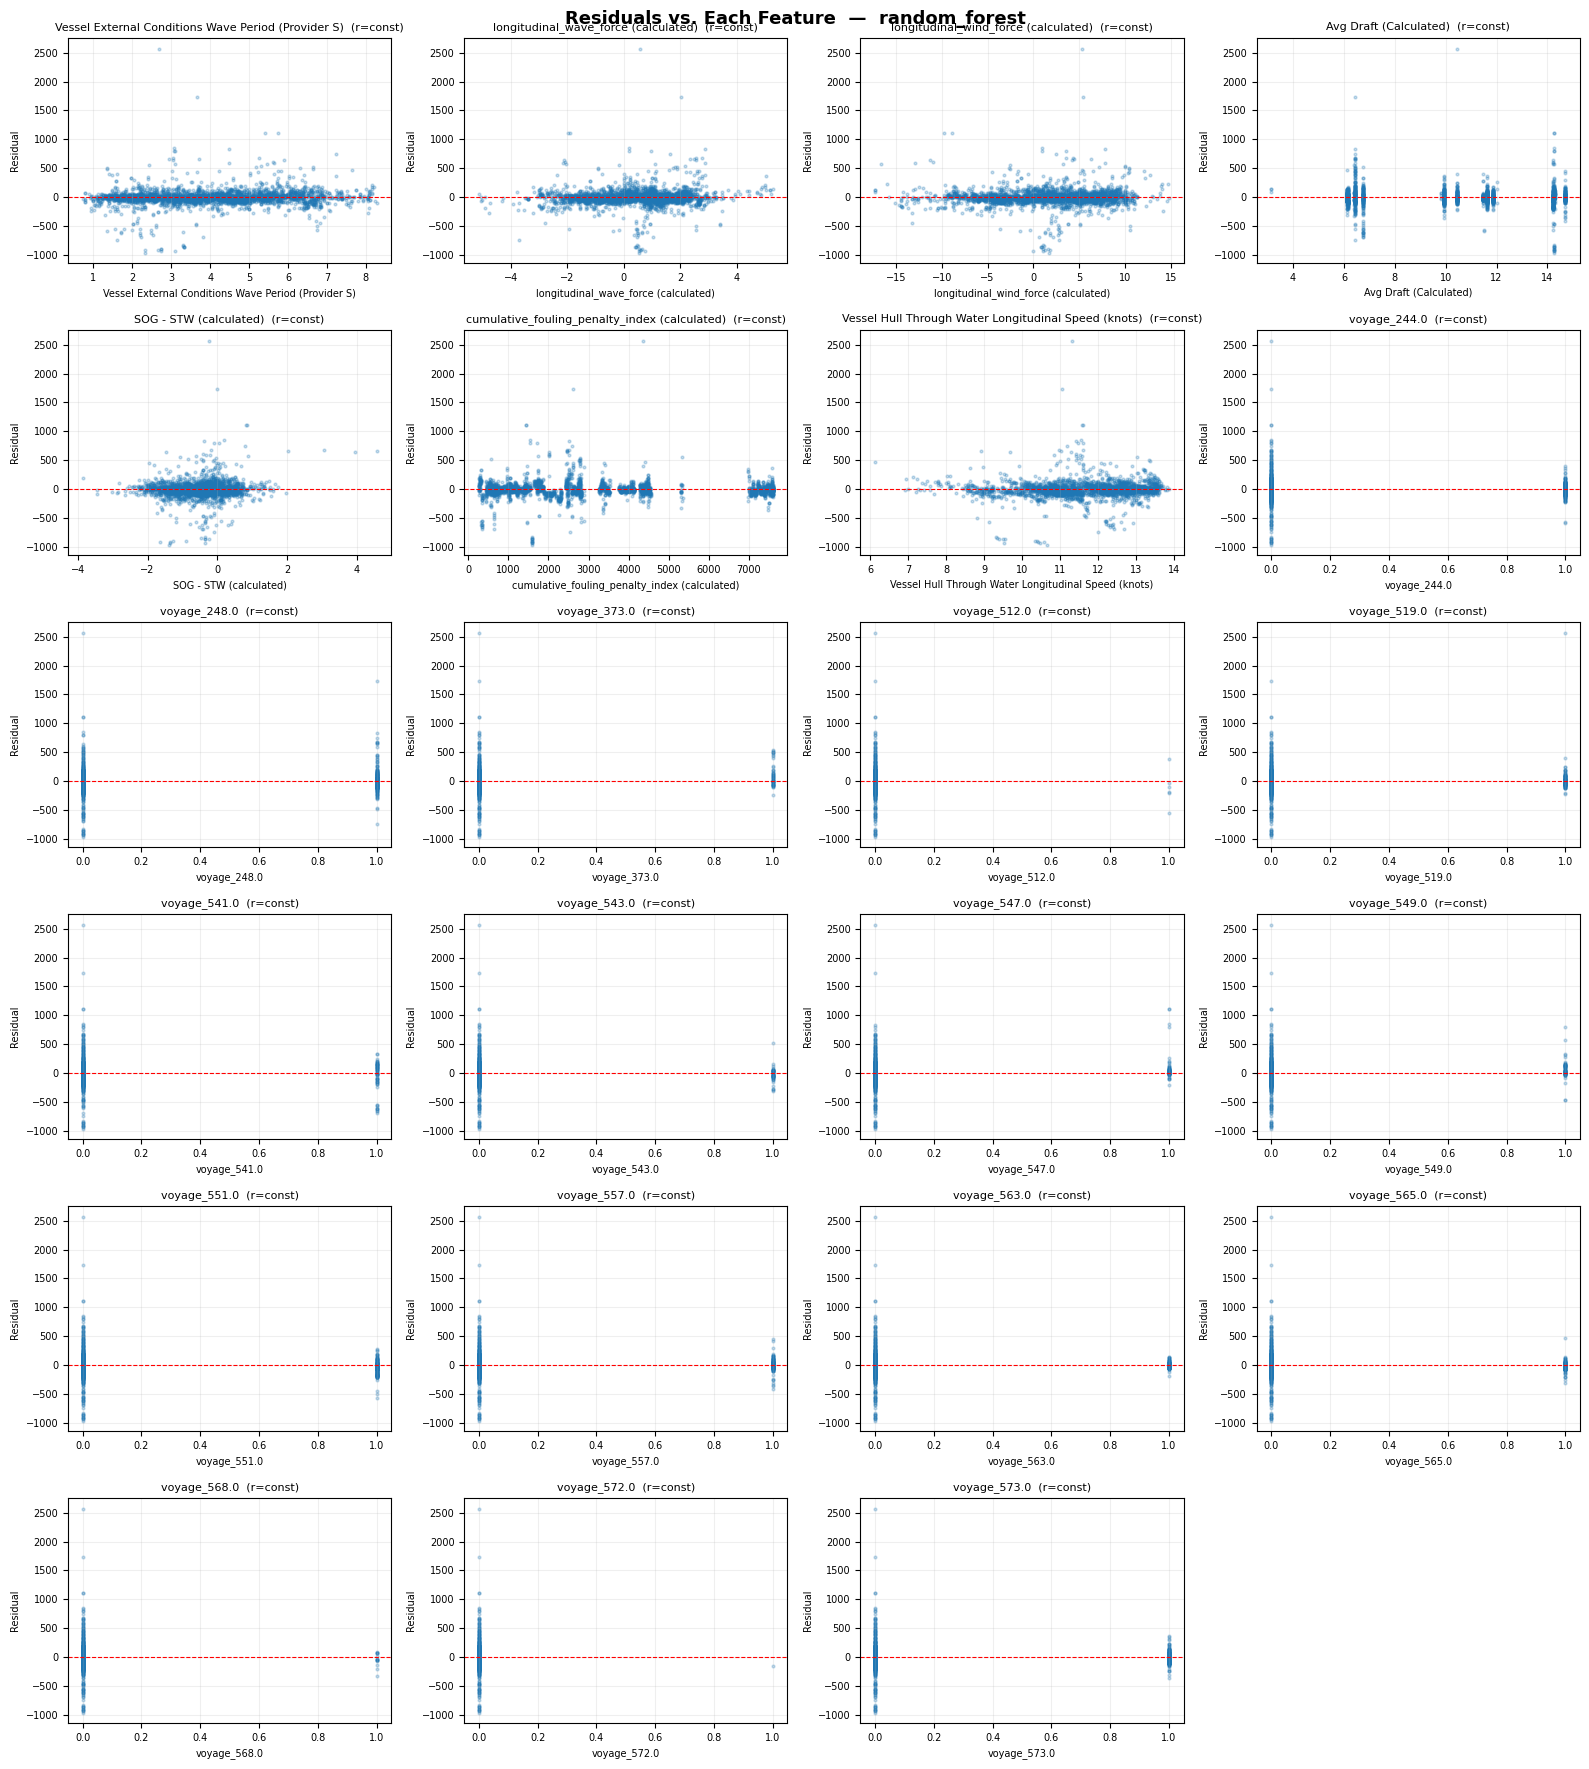

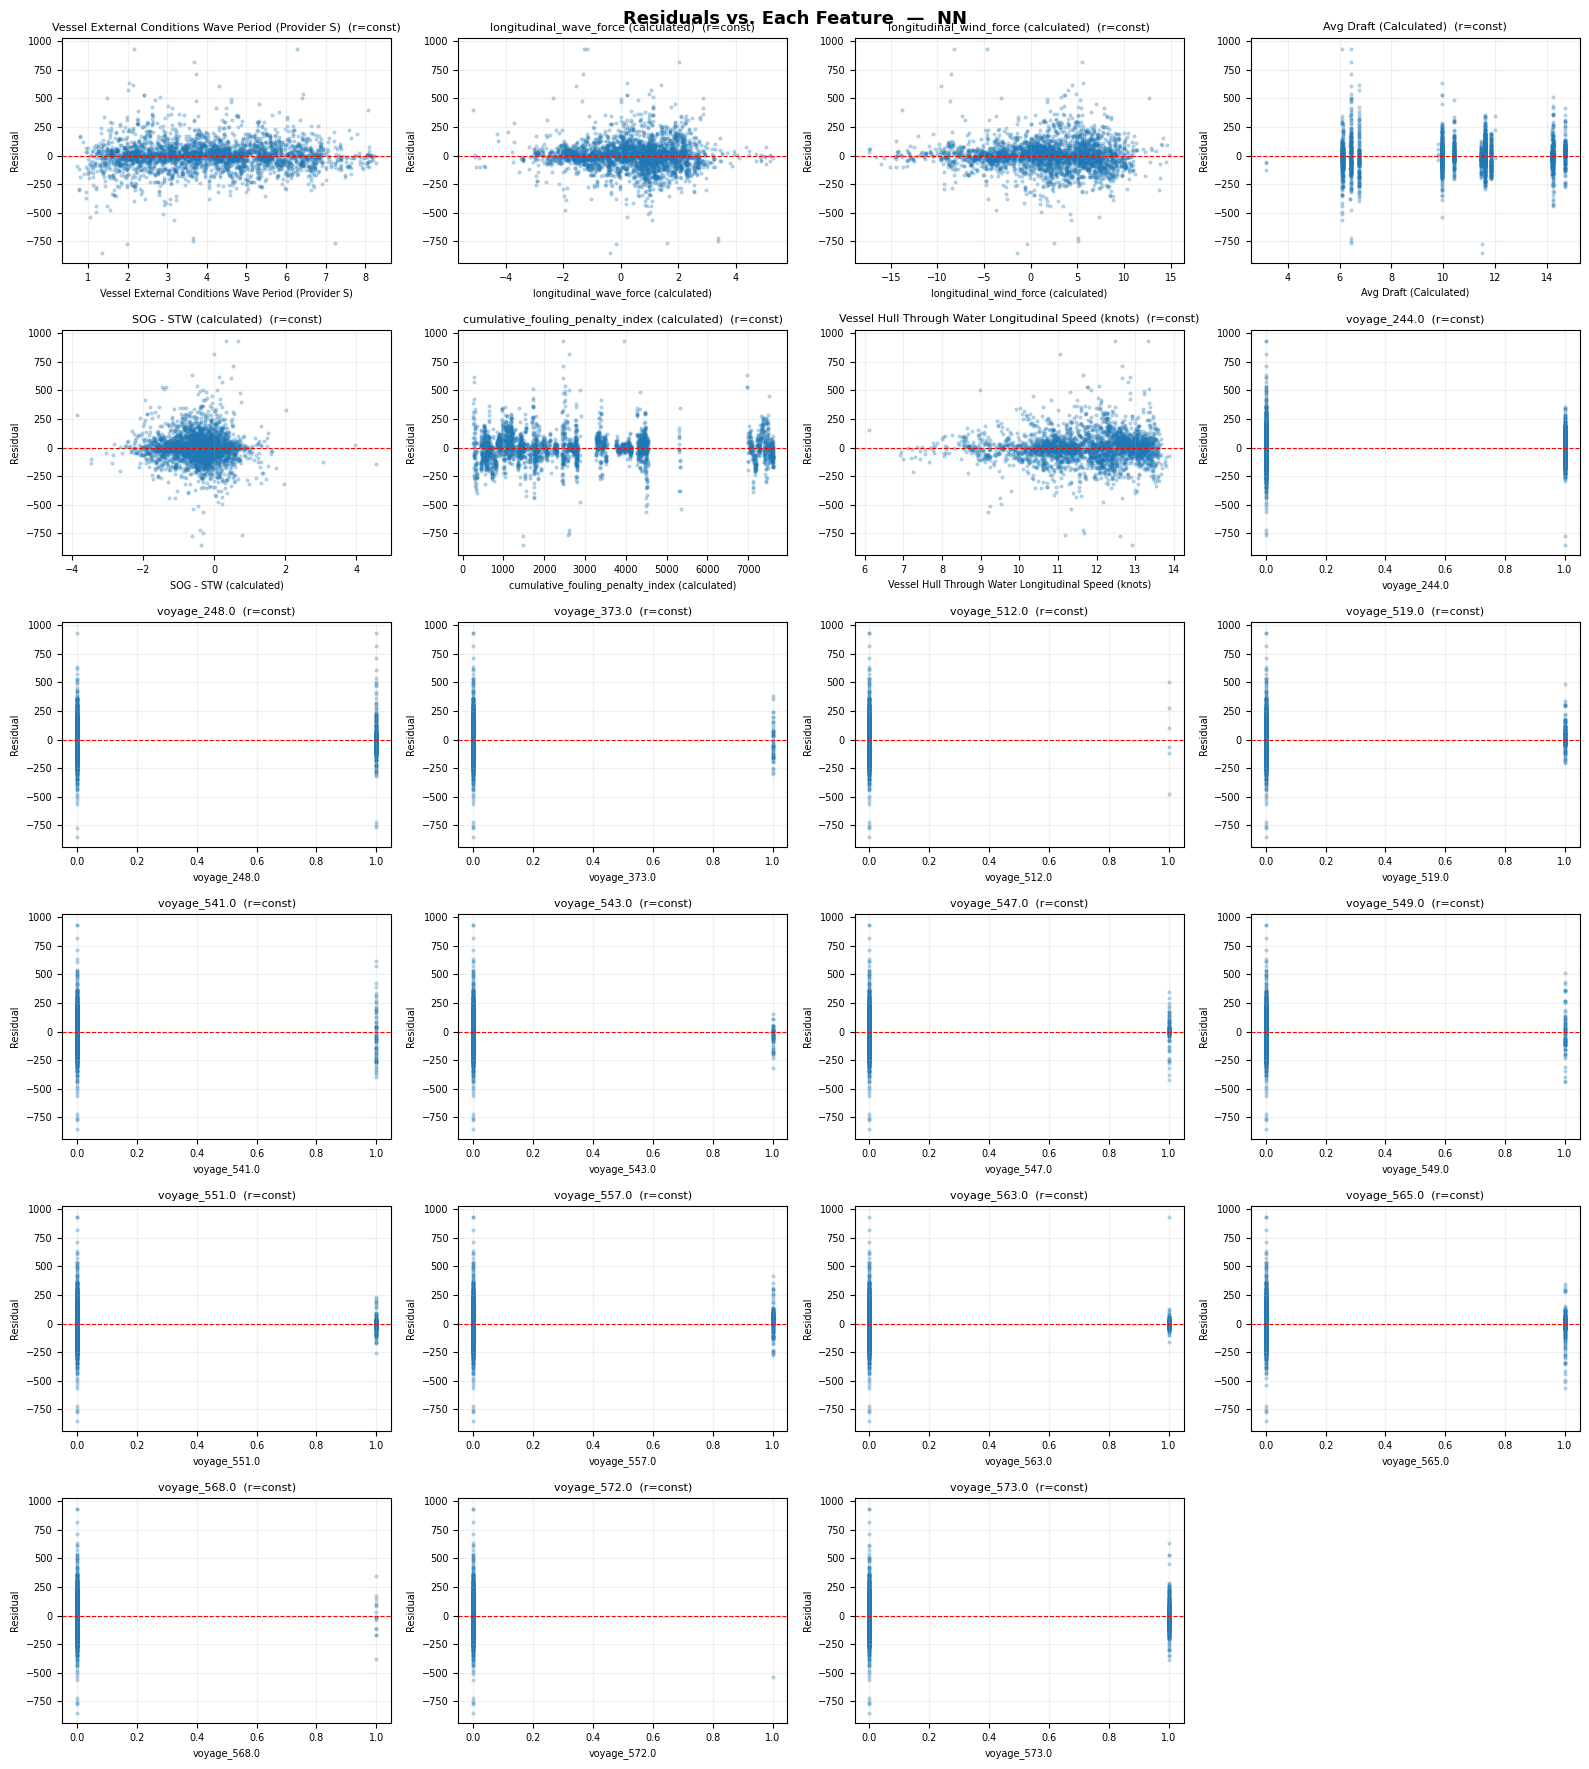


Correlation of each feature with model residuals:


,Vessel External Conditions Wave Period (Provider S),longitudinal_wave_force (calculated),longitudinal_wind_force (calculated),Avg Draft (Calculated),SOG - STW (calculated),cumulative_fouling_penalty_index (calculated),Vessel Hull Through Water Longitudinal Speed (knots),voyage_244.0,voyage_248.0,voyage_373.0,voyage_512.0,voyage_519.0,voyage_541.0,voyage_543.0,voyage_547.0,voyage_549.0,voyage_551.0,voyage_557.0,voyage_563.0,voyage_565.0,voyage_568.0,voyage_572.0,voyage_573.0
Model \ Feature,,,,,,,,,,,,,,,,,,,,,,,
ridge_regression,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
GAM,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
random_forest,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
NN,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


In [69]:
corr_df = plot_residuals_by_feature(model_pipelines_incl_foul, X_test, y_test)

# 3. Analysis

## 3.1. GAM - specific

### 3.1.1.  Partial effect of fouling

In [70]:
def visualize_fouling_dependence(
    X: pd.DataFrame,
    speed_foul_tensor: bool = True,
    n_grid: int = 100,
    figsize_2d: tuple = (8, 6),
    figsize_3d: tuple = (10, 7),
):
    # ── 1. Extract internals ────────────────────────────────────────────────
    pipeline     = model_pipelines_incl_foul["GAM"]
    feature_cols = list(pipeline.named_steps["preprocessor"].transformers[0][2])
    gam_model    = pipeline.named_steps["model"].gam_model_
    scaler       = pipeline.named_steps["preprocessor"].transformers_[0][1]

    X_scaled = pipeline.named_steps["preprocessor"].transform(X)

    fouling_idx = feature_cols.index(FOULING_PROXY_VAR_NAME_WITH_UNIT)
    speed_idx   = feature_cols.index(SPEED_VARIABLE)

    # ── 2. Find term index ──────────────────────────────────────────────────
    def find_term_index(gam, feature_idx, is_tensor=False):
        for i, term in enumerate(gam.terms):
            if is_tensor:
                if getattr(term, "istensor", False):
                    return i
            else:
                if not getattr(term, "istensor", False):
                    if getattr(term, "feature", None) == feature_idx:
                        return i
        raise ValueError(f"Could not locate term for feature index {feature_idx}")

    def inv_scale(values, col_idx):
        return values * scaler.scale_[col_idx] + scaler.mean_[col_idx]

    # ── 3a. 2D plot – additive fouling term ─────────────────────────────────
    if not speed_foul_tensor:
        term_idx = find_term_index(gam_model, fouling_idx, is_tensor=False)

        X_grid_2d = gam_model.generate_X_grid(term=term_idx)
        pdep, confi = gam_model.partial_dependence(
            term=term_idx, X=X_grid_2d, width=0.95
        )
        foul_orig     = inv_scale(X_grid_2d[:, fouling_idx], fouling_idx)
        foul_raw_orig = inv_scale(X_scaled[:, fouling_idx], fouling_idx)

        # ── Stacked layout: PDP on top, histogram below ─────────────────────
        fig, (ax_pdp, ax_hist) = plt.subplots(
            2, 1,
            figsize=figsize_2d,
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
        )

        # Partial dependence
        ax_pdp.plot(foul_orig, pdep, color="steelblue", linewidth=2, label="Partial effect")
        ax_pdp.fill_between(
            foul_orig,
            confi[:, 0],
            confi[:, 1],
            alpha=0.25,
            color="steelblue",
            label="95% CI",
        )
        ax_pdp.set_ylabel("Partial effect on shaft power (kW)")
        ax_pdp.set_title("GAM – Partial Effect of Fouling Proxy")
        ax_pdp.legend()
        ax_pdp.grid(alpha=0.3)
        ax_pdp.tick_params(labelbottom=False)  # hide x-tick labels on top plot

        # Histogram of observed fouling values
        ax_hist.hist(
            foul_raw_orig,
            bins=50,
            color="steelblue",
            alpha=0.6,
            edgecolor="none",
        )
        ax_hist.set_xlabel(FOULING_PROXY_VAR_NAME_WITH_UNIT)
        ax_hist.set_ylabel("Count")
        ax_hist.grid(alpha=0.3)
        ax_hist.yaxis.set_major_locator(plt.MaxNLocator(3, integer=True))  # keep it tidy

        plt.tight_layout()
        plt.show()

    # ── 3b. 3D plot – tensor product speed × fouling ────────────────────────
    else:
        term_idx = find_term_index(gam_model, speed_idx, is_tensor=True)

        speed_lin = np.linspace(
            np.percentile(X_scaled[:, speed_idx], 5),
            np.percentile(X_scaled[:, speed_idx], 95),
            n_grid,
        )
        foul_lin = np.linspace(
            np.percentile(X_scaled[:, fouling_idx], 5),
            np.percentile(X_scaled[:, fouling_idx], 95),
            n_grid,
        )
        speed_grid_scaled, foul_grid_scaled = np.meshgrid(speed_lin, foul_lin)
        n_points = n_grid * n_grid

        col_means   = X_scaled.mean(axis=0)
        X_grid_full = np.tile(col_means, (n_points, 1))
        X_grid_full[:, speed_idx]   = speed_grid_scaled.ravel()
        X_grid_full[:, fouling_idx] = foul_grid_scaled.ravel()

        Z_baseline = gam_model.predict(np.tile(col_means, (1, 1)))[0]
        Z = gam_model.predict(X_grid_full).reshape(n_grid, n_grid) - Z_baseline

        speed_orig = inv_scale(speed_grid_scaled, speed_idx)
        foul_orig  = inv_scale(foul_grid_scaled,  fouling_idx)

        fig = plt.figure(figsize=figsize_3d)
        ax  = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(
            speed_orig, foul_orig, Z,
            cmap="viridis", alpha=0.85, linewidth=0, antialiased=True,
        )
        fig.colorbar(surf, ax=ax, shrink=0.5, label="Partial effect (kW)")
        ax.set_xlabel(SPEED_VARIABLE)
        ax.set_ylabel(FOULING_PROXY_VAR_NAME_WITH_UNIT)
        ax.set_zlabel("Δ Shaft power vs. mean conditions (kW)")
        ax.set_title("GAM – Speed × Fouling: Effect on Shaft Power")
        plt.tight_layout()
        plt.show()

C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3755351504.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


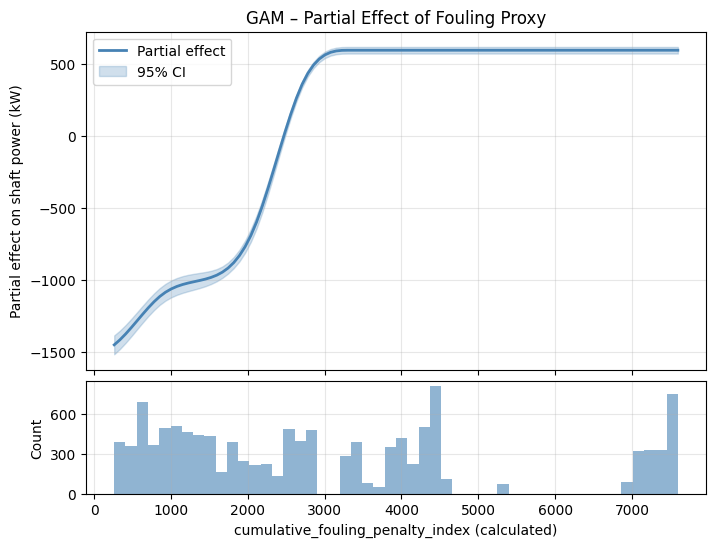

In [71]:
visualize_fouling_dependence(
    X=X_train,
    speed_foul_tensor = False,
)

### 3.1.2. Partial effect of other features

In [72]:
def visualize_all_terms_with_hist(
    X: pd.DataFrame,
    pipeline,
    n_grid: int = 100,
    n_cols: int = 2,              # 2 features per row
    figsize_per_col: tuple = (6, 4),
):
    """
    For each 1D GAM term: stacked layout (PDP + histogram), arranged with
    `n_cols` features per row, each feature looking like visualize_fouling_dependence.
    """
    # ── 1. Extract internals ────────────────────────────────────────────────
    feature_cols = list(pipeline.named_steps["preprocessor"].transformers[0][2])
    n_continuous = len(feature_cols)
    gam_model    = pipeline.named_steps["model"].gam_model_
    scaler       = pipeline.named_steps["preprocessor"].transformers_[0][1]

    X_scaled = pipeline.named_steps["preprocessor"].transform(X)

    def inv_scale(values, col_idx):
        return values * scaler.scale_[col_idx] + scaler.mean_[col_idx]

    # Collect indices of all non‑intercept, non‑tensor, continuous terms
    # (skip voyage dummies — PDP on binary 0/1 features is not meaningful)
    term_info = []
    for term_idx, term in enumerate(gam_model.terms):
        if term.isintercept:
            continue
        if getattr(term, "istensor", False):
            continue
        col_idx = term.feature
        if col_idx >= n_continuous:
            continue
        term_info.append((term_idx, col_idx))

    n_terms = len(term_info)
    if n_terms == 0:
        print("No 1D terms found.")
        return

    # ── 2. Prepare figure grid ──────────────────────────────────────────────
    n_rows = int(np.ceil(n_terms / n_cols))
    # 2 rows per feature (PDP + hist)
    fig_width  = figsize_per_col[0] * n_cols
    fig_height = figsize_per_col[1] * 2 * n_rows

    fig, axes = plt.subplots(
        n_rows * 2,
        n_cols,
        figsize=(fig_width, fig_height),
        sharex=False,
        gridspec_kw={"hspace": 0.35},
    )
    axes = np.atleast_2d(axes)

    # ── 3. Loop over terms ──────────────────────────────────────────────────
    for k, (term_idx, col_idx) in enumerate(term_info):
        term      = gam_model.terms[term_idx]
        feat_name = feature_cols[col_idx]

        # grid + partial dependence in scaled space
        X_grid = gam_model.generate_X_grid(term=term_idx)
        pdep, confi = gam_model.partial_dependence(
            term=term_idx, X=X_grid, width=0.95
        )

        x_grid_orig = inv_scale(X_grid[:, col_idx], col_idx)
        x_raw_orig  = inv_scale(X_scaled[:, col_idx], col_idx)

        row = k // n_cols
        col = k % n_cols

        ax_pdp  = axes[2 * row,     col]
        ax_hist = axes[2 * row + 1, col]

        # ── PDP (same style as fouling plot) ────────────────────────────────
        ax_pdp.plot(
            x_grid_orig,
            pdep,
            color="steelblue",
            linewidth=2,
            label="Partial effect",
        )
        ax_pdp.fill_between(
            x_grid_orig,
            confi[:, 0],
            confi[:, 1],
            alpha=0.25,
            color="steelblue",
            label="95% CI",
        )
        ax_pdp.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
        ax_pdp.set_ylabel("Partial effect")
        ax_pdp.set_title(feat_name)
        ax_pdp.grid(alpha=0.3)
        ax_pdp.tick_params(labelbottom=False)

        # Add legend only to first subplot to save space
        if k == 0:
            ax_pdp.legend()

        # ── Histogram (same style as fouling plot) ──────────────────────────
        ax_hist.hist(
            x_raw_orig,
            bins=50,
            color="steelblue",
            alpha=0.6,
            edgecolor="none",
        )
        ax_hist.set_xlabel(feat_name)
        ax_hist.set_ylabel("Count")
        ax_hist.grid(alpha=0.3)
        ax_hist.yaxis.set_major_locator(plt.MaxNLocator(3, integer=True))

    # Hide any unused axes
    total_cells = (n_rows * 2) * n_cols
    used_cells  = len(term_info) * 2
    if used_cells < total_cells:
        for i in range(used_cells, total_cells):
            axes.flat[i].set_visible(False)

    plt.tight_layout()
    plt.show()

C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\2486992578.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


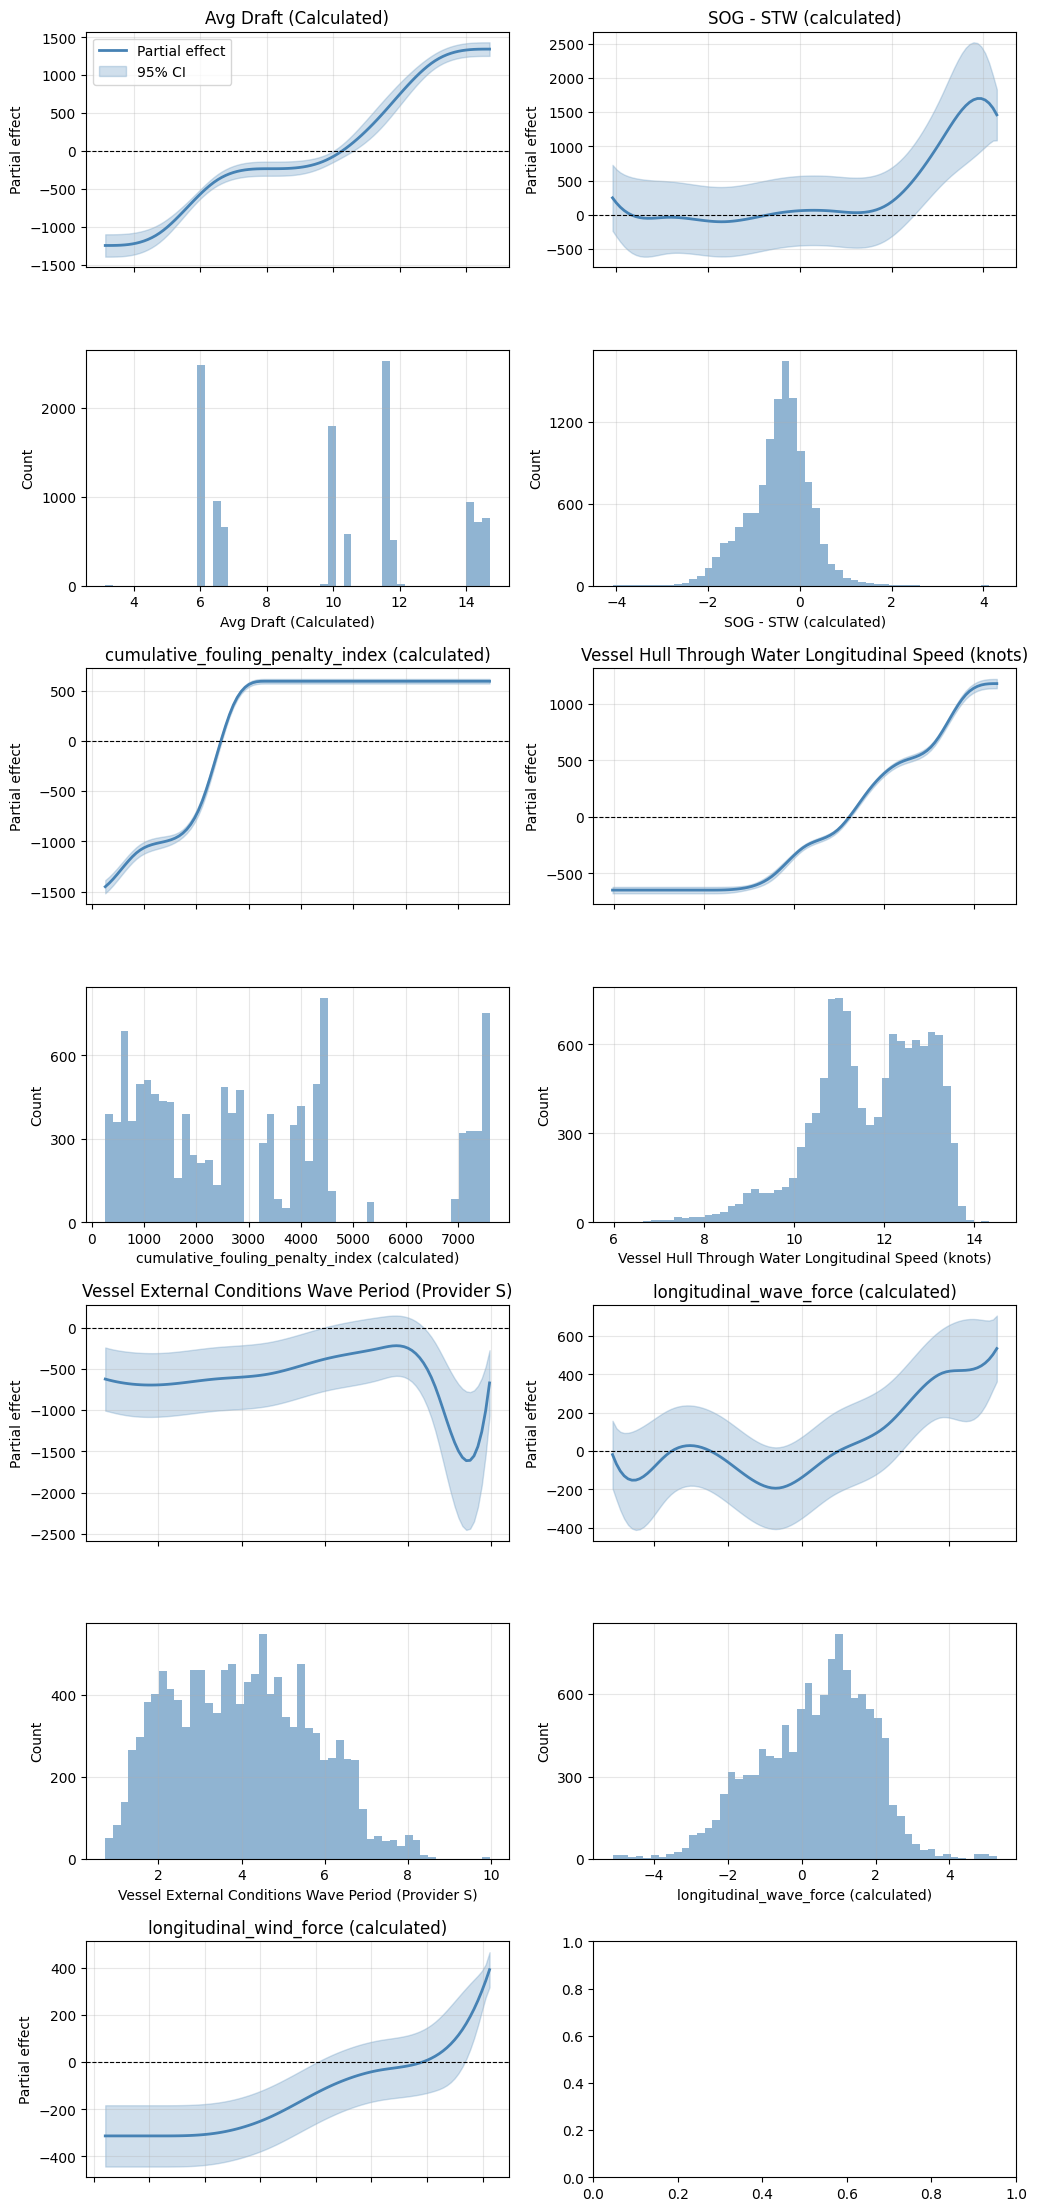

In [73]:
visualize_all_terms_with_hist(
    X=X_train,
    pipeline=model_pipelines_incl_foul["GAM"],
    n_grid=100,
    n_cols=2,                    # two features per line
    figsize_per_col=(6, 4),      # tweak if still cramped
)


## 3.2. Black Box-specific

### 3.2.1. Partial dependence on speed (pseudo speed-power curves)

### 3.2.2. ICE plots

What we want to see is nice and upward sloping curves that are somewhat parallel, especially when stratifying

In [74]:
rf_model_incl_fouling = model_pipelines_incl_foul["random_forest"].named_steps["model"]
nn_model_incl_fouling = model_pipelines_incl_foul["NN"].named_steps["model"]

black_boxes = {
    "Random Forest": rf_model_incl_fouling,
    "Neural Network": nn_model_incl_fouling,
}

preprocessors = {
    "Random Forest": model_pipelines_incl_foul["random_forest"].named_steps["preprocessor"],
    "Neural Network": model_pipelines_incl_foul["NN"].named_steps["preprocessor"],
}

In [96]:
from typing import Optional, List

def plot_ice_with_optional_strata(
    model,
    preprocess,
    X: pd.DataFrame,
    feature_name: str,
    group_mask=None,
    model_name_for_title=None,
    n_samples: int = 200,
    grid_points: int = 60,
    alpha_ice: float = 0.08,
    color_ice: str = "tab:blue",
    color_pdp: str = "black",
    title_prefix: str = "",
    random_state: int = 42,
    valid_data_space: Optional[List[float]] = None,
):
    """
    Plot ICE curves and PDP for a single feature, with optional stratification,
    plus a histogram of the feature to show data coverage.

    valid_data_space : list[float] or None
        If provided, must be [lower, upper]. Values of the feature outside this
        interval are treated as 'low data coverage' and shaded in grey in the
        ICE/PDP panel. Min/max PDP markers are computed only inside this interval.
    """

    # 1. Determine which observations to use
    if group_mask is not None:
        if isinstance(group_mask, (pd.Series, np.ndarray, list)):
            if isinstance(group_mask, (pd.Series, np.ndarray)) and getattr(group_mask, "dtype", None) == bool:
                X_sub = X.loc[group_mask].copy()
            else:
                X_sub = X.loc[group_mask].copy()
        else:
            raise ValueError("group_mask must be a boolean mask or index-like.")
    else:
        X_sub = X.copy()

    if len(X_sub) == 0:
        raise ValueError("No rows selected for ICE after applying group_mask.")

    rng = np.random.default_rng(random_state)
    n_samples = min(n_samples, len(X_sub))
    sample_idx = rng.choice(len(X_sub), size=n_samples, replace=False)
    X_sample = X_sub.iloc[sample_idx].copy()

    # 2. Build feature grid (central observed range)
    f_min, f_max = X[feature_name].quantile([0.01, 0.99])
    feature_grid = np.linspace(f_min, f_max, grid_points)

    ice_vals = np.zeros((n_samples, grid_points))

    # 3. For each grid value, replace the feature, preprocess, and predict
    for j, val in enumerate(feature_grid):
        X_tmp = X_sample.copy()
        X_tmp[feature_name] = val
        X_tmp_trans = preprocess.transform(X_tmp)
        ice_vals[:, j] = model.predict(X_tmp_trans)

    pdp_vals = ice_vals.mean(axis=0)

    # 4. Plot ICE + PDP with histogram below
    fig = plt.figure(figsize=(8, 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

    ax_main = fig.add_subplot(gs[0, 0])
    ax_hist = fig.add_subplot(gs[1, 0], sharex=ax_main)

    # ICE curves
    for i in range(ice_vals.shape[0]):
        ax_main.plot(feature_grid, ice_vals[i, :],
                     color=color_ice, alpha=alpha_ice, linewidth=0.7)

    # PDP curve
    ax_main.plot(feature_grid, pdp_vals,
                 color=color_pdp, linewidth=2.0, label="PDP (mean ICE)")

    ax_main.set_ylabel("Predicted Vessel Propeller Shaft Mechanical Power (kW)")
    ax_main.grid(True, alpha=0.3)
    ax_main.legend()

    if title_prefix:
        title = f"{title_prefix} – ICE & PDP for {feature_name} ({model_name_for_title})"
    else:
        title = f"ICE & PDP for {feature_name}"
    ax_main.set_title(title)

    # Preserve y-limits for later
    y_min, y_max = ax_main.get_ylim()

    # 4a. Shade low-data regions, if requested
    if valid_data_space is not None:
        if (
            not isinstance(valid_data_space, (list, tuple)) or
            len(valid_data_space) != 2
        ):
            raise ValueError("valid_data_space must be a list/tuple of two floats [low, high].")
        v_low, v_high = float(valid_data_space[0]), float(valid_data_space[1])

        # Helper to add shading and label once per side
        def shade_region(x0, x1):
            if x1 <= x0:
                return
            ax_main.axvspan(x0, x1,
                            ymin=0, ymax=1,
                            color="lightgrey", alpha=0.4,
                            zorder=-1)
            x_text = (x0 + x1) / 2.0
            ax_main.text(
                x_text,
                y_max - 0.05 * (y_max - y_min),
                "low data coverage",
                color="dimgray",
                fontsize=9,
                ha="center",
                va="top",
                alpha=0.9,
            )

        # Left low-data region
        if v_low > f_min:
            shade_region(f_min, v_low)

        # Right low-data region
        if v_high < f_max:
            shade_region(v_high, f_max)

        # Min/max markers restricted to valid interval
        valid_mask = (feature_grid >= v_low) & (feature_grid <= v_high)
    else:
        # No restriction: all grid points are "valid"
        valid_mask = np.ones_like(feature_grid, dtype=bool)

    # Restore y-limits in case shading changed them
    ax_main.set_ylim(y_min, y_max)

    # 4b. Mark min and max PDP within valid data area
    if valid_mask.any():
        fg_valid = feature_grid[valid_mask]
        pdp_valid = pdp_vals[valid_mask]

        min_idx = np.argmin(pdp_valid)
        max_idx = np.argmax(pdp_valid)

        x_min, y_min_pdp = fg_valid[min_idx], pdp_valid[min_idx]
        x_max, y_max_pdp = fg_valid[max_idx], pdp_valid[max_idx]

        ax_main.scatter([x_min], [y_min_pdp], color="green", s=40, zorder=5)
        ax_main.scatter([x_max], [y_max_pdp], color="green", s=40, zorder=5)

        ax_main.text(
            x_min,
            y_min_pdp - 0.03 * (y_max - y_min),
            f"min: {y_min_pdp:.0f}",
            color="green",
            fontsize=9,
            ha="center",
            va="top",
        )
        ax_main.text(
            x_max,
            y_max_pdp + 0.03 * (y_max - y_min),
            f"max: {y_max_pdp:.0f}",
            color="green",
            fontsize=9,
            ha="center",
            va="bottom",
        )

    # Histogram of data coverage (subset used for ICE)
    ax_hist.hist(X_sub[feature_name], bins=30, color="tab:blue", alpha=0.6)
    ax_hist.set_ylabel("Count")
    ax_hist.set_xlabel(feature_name)

    # Remove x tick labels from main plot
    plt.setp(ax_main.get_xticklabels(), visible=False)

    plt.tight_layout()
    plt.show()


C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


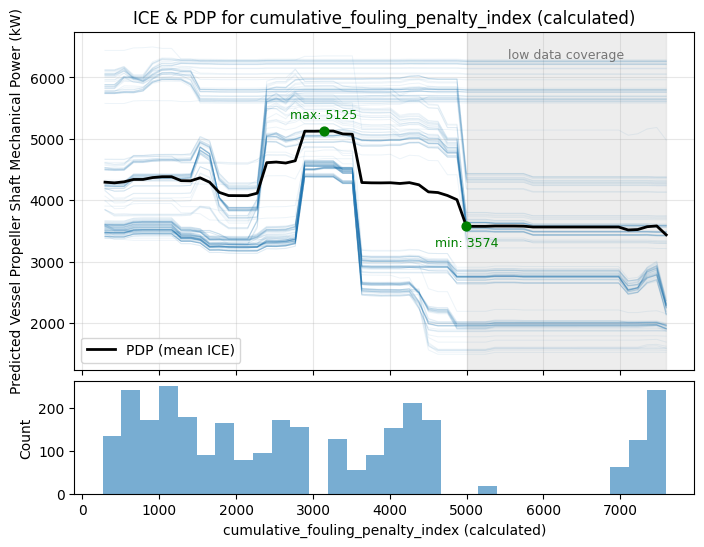

C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


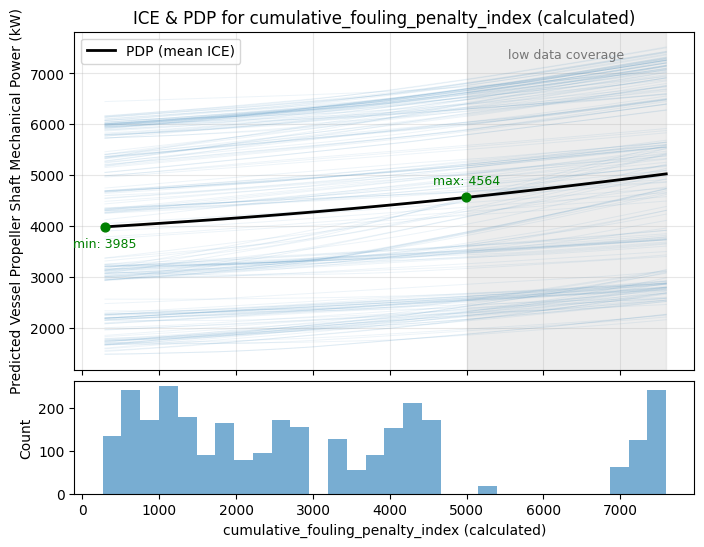

In [97]:
for model_name, model in black_boxes.items():
    plot_ice_with_optional_strata(
        model=model,             # RF trained on preprocessed data
        preprocess=preprocessors[model_name],                   # your fitted scaler / ColumnTransformer
        X=X_test,                           # raw validation features (DataFrame)
        feature_name= FOULING_PROXY_VAR_NAME_WITH_UNIT,
        model_name_for_title=model_name,
        valid_data_space=[0.0,5000.0]
    ,
    )

In [102]:
4564/3985

1.1452948557089084

C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


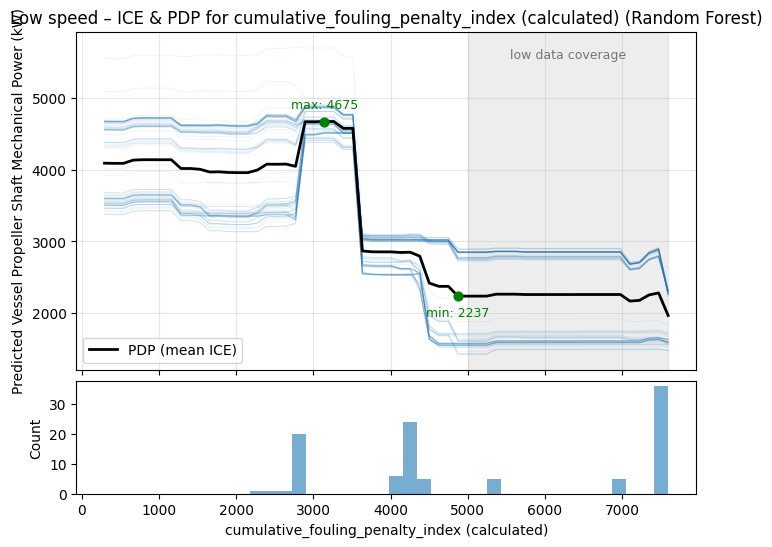

C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


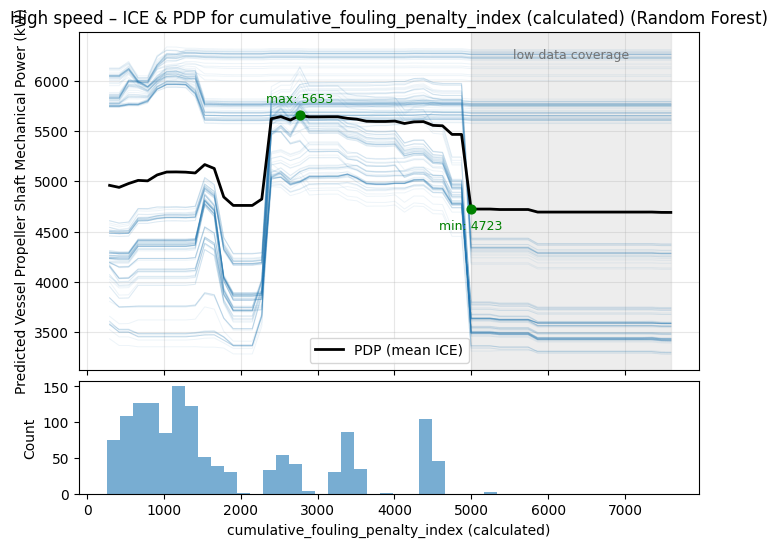

C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


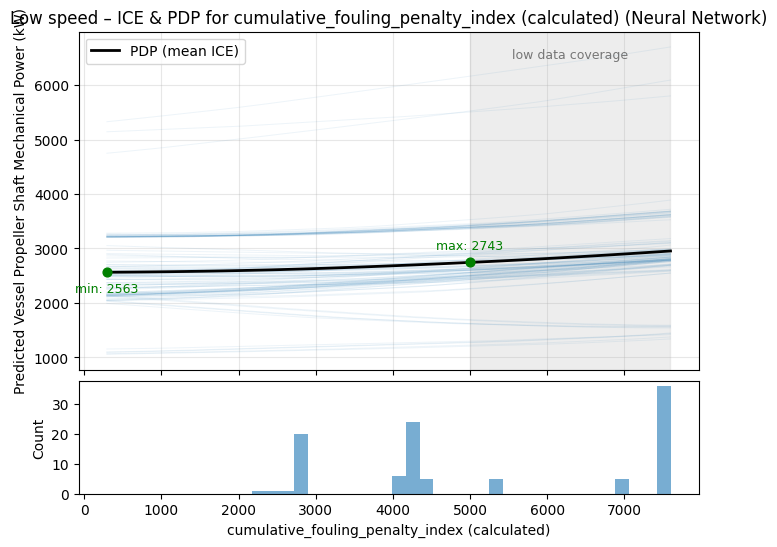

C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


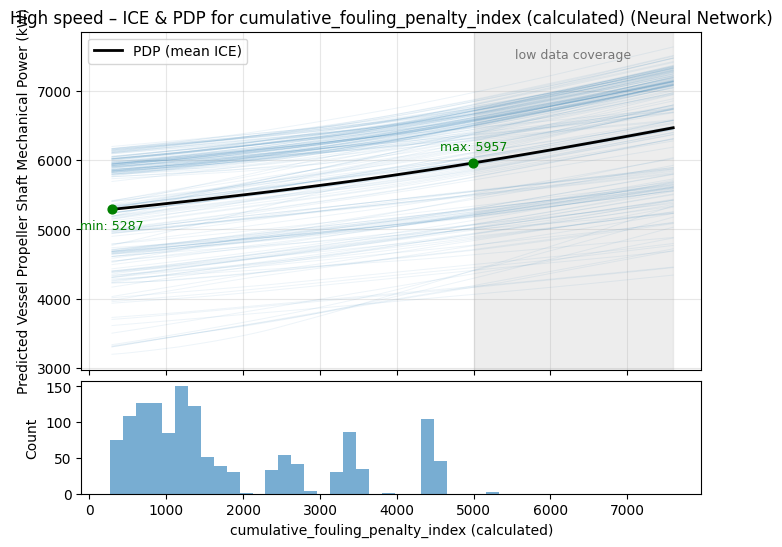

In [ ]:
speed_col = "Vessel Hull Through Water Longitudinal Speed (knots)"
fouling_col = FOULING_PROXY_VAR_NAME_WITH_UNIT

# Define speed bands (adjust thresholds to your data)
low_speed_mask  = X_test[speed_col] < 10
high_speed_mask = X_test[speed_col] >= 12

for model_name, model in black_boxes.items():
    # Low-speed ICE for fouling
    plot_ice_with_optional_strata(
        model=model,
        preprocess=preprocessors[model_name],
        X=X_test,
        feature_name=fouling_col,
        group_mask=low_speed_mask,
        title_prefix="Low speed",
        model_name_for_title=model_name,
        valid_data_space=[0.0,5000.0]
    )

    # High-speed ICE for fouling
    plot_ice_with_optional_strata(
        model=model,
        preprocess=preprocessors[model_name],
        X=X_test,
        feature_name=fouling_col,
        group_mask=high_speed_mask,
        title_prefix="High speed",
        model_name_for_title=model_name,
        valid_data_space=[0.0,5000.0]
    )


In [101]:
2743/2563

1.0702301989855638

Draft 6.42 m: 222 observations in [6.32, 6.52]


C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


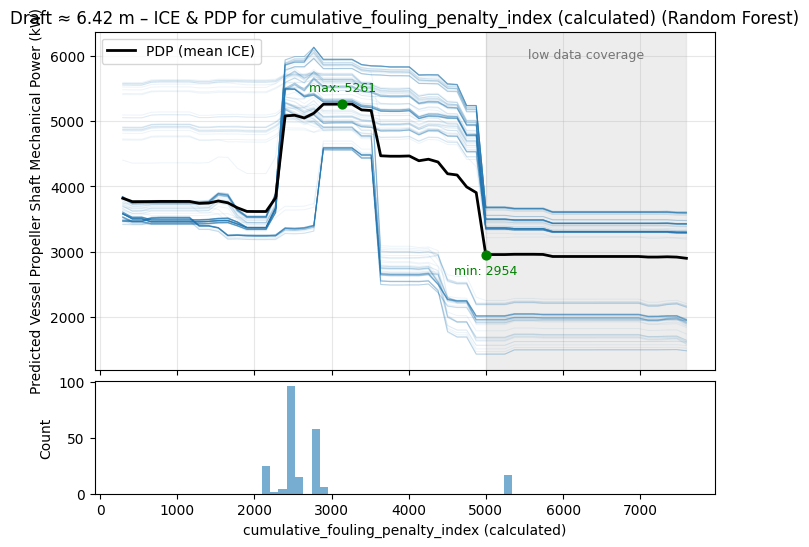

Draft 6.75 m: 142 observations in [6.65, 6.85]


C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


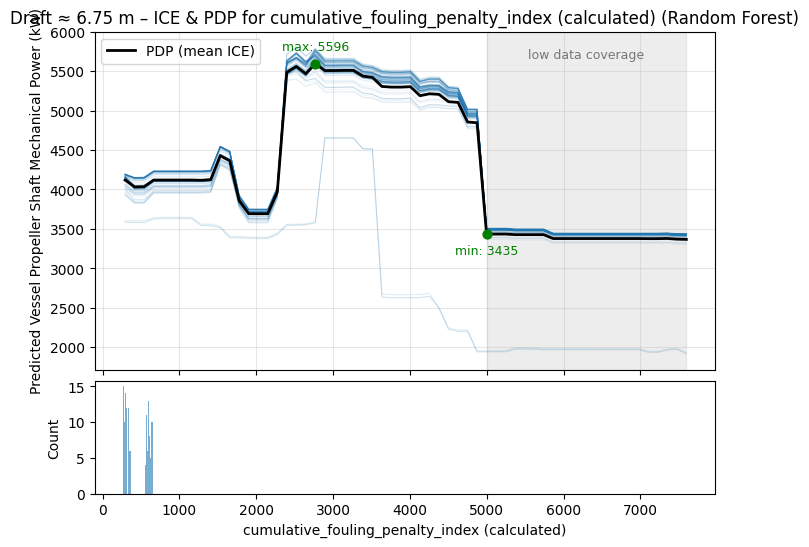

Draft 14.25 m: 437 observations in [14.15, 14.35]


C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


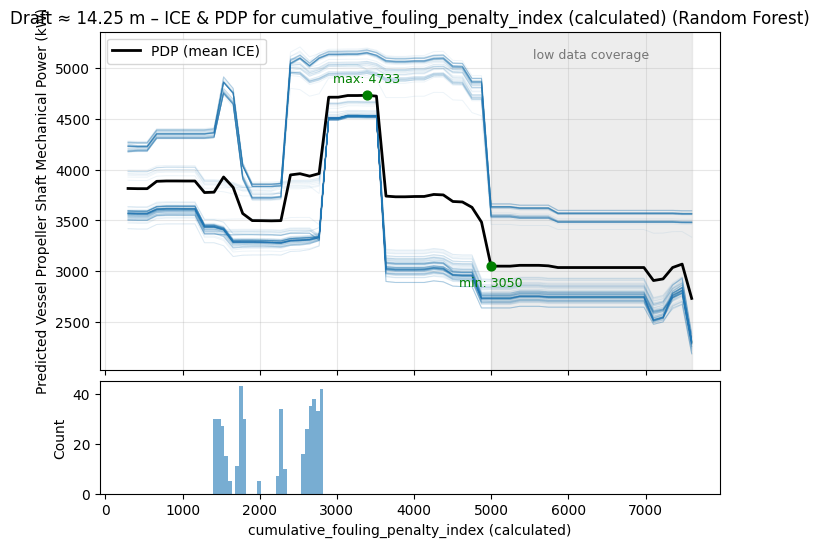

Draft 6.42 m: 222 observations in [6.32, 6.52]


C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


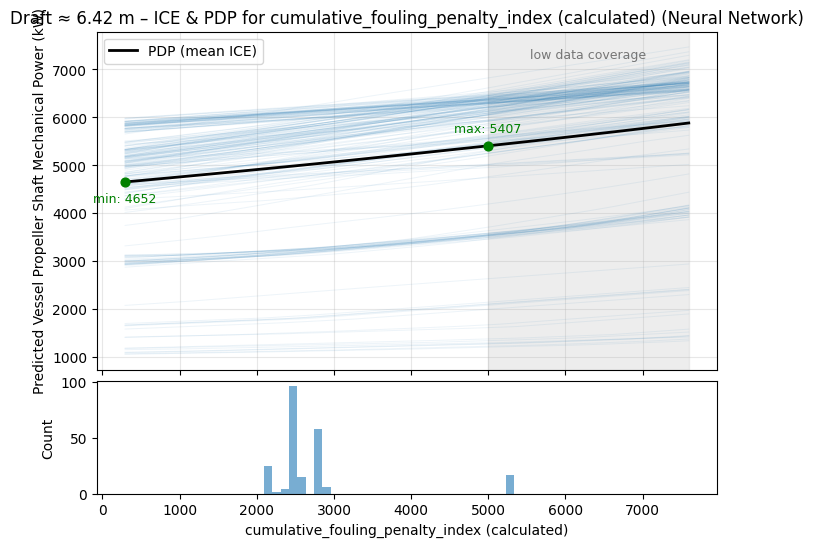

Draft 6.75 m: 142 observations in [6.65, 6.85]


C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


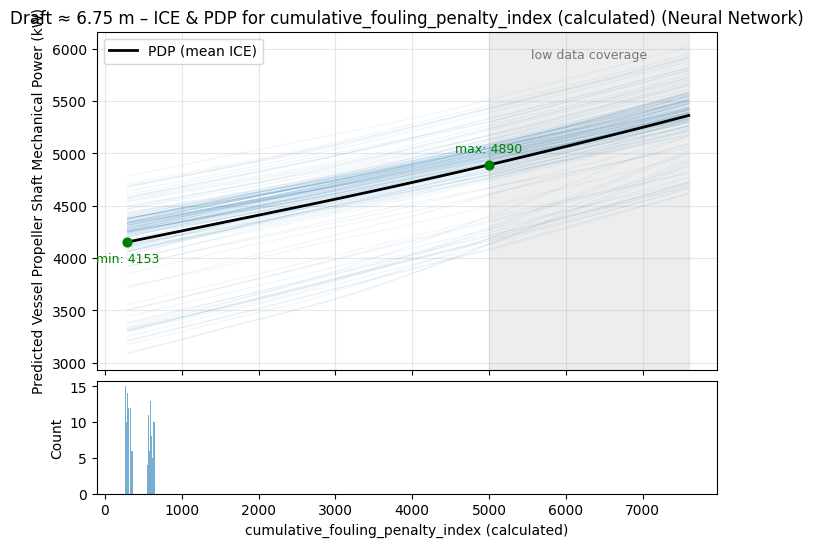

Draft 14.25 m: 437 observations in [14.15, 14.35]


C:\Users\Augus\AppData\Local\Temp\ipykernel_42108\3800091524.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


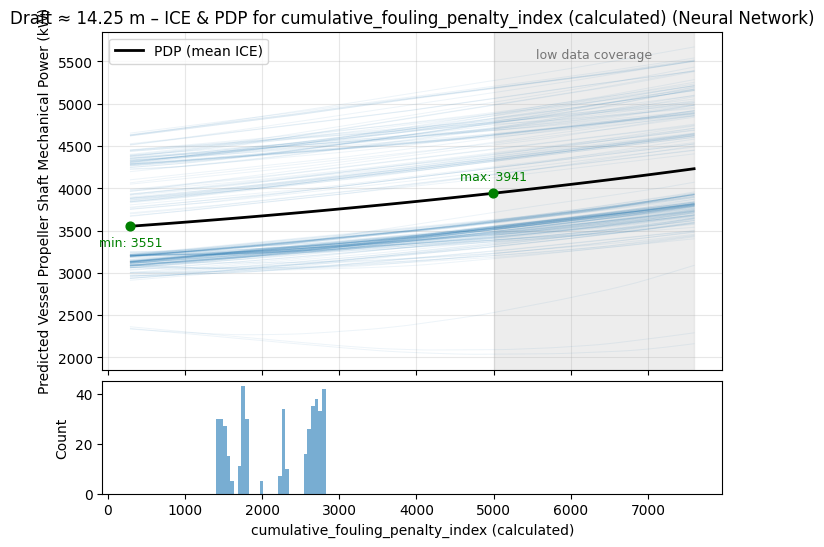

In [99]:
draft_col = "Avg Draft (Calculated)"
drafts_to_test = [6.42, 6.75, 14.25]
tol = 0.1  # meters
fouling_col = FOULING_PROXY_VAR_NAME_WITH_UNIT


for model_name, model in black_boxes.items():
    for target_draft in drafts_to_test:
        mask = (
            (X_test[draft_col] >= target_draft - tol) &
            (X_test[draft_col] <= target_draft + tol)
        )

        print(
            f"Draft {target_draft:.2f} m: "
            f"{mask.sum()} observations in [{target_draft - tol:.2f}, {target_draft + tol:.2f}]"
        )

        if mask.sum() < 20:   # require a minimum sample size
            continue

        plot_ice_with_optional_strata(
            model=model,
            preprocess=preprocessors[model_name],
            X=X_test,
            feature_name=fouling_col,
            group_mask=mask,
            title_prefix=f"Draft ≈ {target_draft:.2f} m",
            n_samples=min(200, mask.sum()),
            model_name_for_title=model_name,
            valid_data_space=[0.0,5000.0]
        )


## 3.3. All models

### 3.3.1. Fouling effect by fouling level

In [79]:
# Paths to the pre-built controlled-variable CSVs
fouling_only_path = os.path.join(train_test_dir, f"controlled_var_{WINDOW_LENGTH}_{FOULING_PROXY_VAR_NAME_WITH_UNIT}.csv")
fouling_speed_path = os.path.join(train_test_dir, f"controlled_var_{WINDOW_LENGTH}_{FOULING_PROXY_VAR_NAME_WITH_UNIT}_{SPEED_VARIABLE}.csv")
fouling_draft_path = os.path.join(train_test_dir, f"controlled_var_{WINDOW_LENGTH}_{FOULING_PROXY_VAR_NAME_WITH_UNIT}_Avg Draft (Calculated).csv")

In [80]:
pipelines_excl_ridge = {
    k: v for k, v in model_pipelines_incl_foul.items()
    if k != "ridge_regression"
}

In [81]:
def load_and_predict_controlled_var(
    controlled_var_path: str,
    model_pipelines: dict,
) -> pd.DataFrame:
    """
    Load a pre-built controlled-variable CSV and add a prediction column
    for every model in the dict.

    Returns the DataFrame with one '<model_name>_pred' column per model.
    """
    df = pd.read_csv(controlled_var_path)
    feature_cols = [c for c in df.columns if c != TARGET_VARIABLE]
    for name, pipeline in model_pipelines.items():
        df[f"{name}_pred"] = pipeline.predict(df[feature_cols])
    return df

def plot_controlled_var_predictions(
    controlled_var_path: str,
    model_pipelines: dict,
    controlled_var_name: str = FOULING_PROXY_VAR_NAME_WITH_UNIT,
    second_controlled_var_name: str | None = None,
    second_controlled_var_values: list | None = None,
    fouling_quantiles: list[float] | None = None,
    figsize: tuple = (12, 7),
):
    """
    Load a controlled-variable CSV, predict with every model, and plot.

    Single-variable case (second_controlled_var_name is None):
        One plot with one line per model — predicted power vs fouling.

    Two-variable case:
        One plot **per model**. X-axis = second variable (e.g. speed),
        Y-axis = predicted shaft power (kW).
        One line per fouling quantile, coloured from clean → fouled.

    Parameters
    ----------
    controlled_var_path : str
        Path to the controlled-variable CSV.
    model_pipelines : dict
        {model_name: fitted_pipeline}.
    controlled_var_name : str
        Primary controlled variable (fouling proxy by default).
    second_controlled_var_name : str or None
        Second controlled variable in the CSV (e.g. speed, draft).
    second_controlled_var_values : list or None
        Specific values of the second variable to include on the x-axis.
        If None, all unique values in the CSV are used.
    fouling_quantiles : list of float, optional
        Quantile fractions (0–1) of the fouling range to keep as
        individual lines.  Default: [0, 0.25, 0.5, 0.75, 1.0].
    figsize : tuple
        Figure size for each plot.
    """
    df = load_and_predict_controlled_var(controlled_var_path, model_pipelines)
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    if second_controlled_var_name is None:
        # ── Single controlled variable: one plot, one line per model ──
        palette = sns.color_palette("tab10", len(pred_cols))
        fig, ax = plt.subplots(figsize=figsize)
        x = df[controlled_var_name]
        for color, col in zip(palette, pred_cols):
            label = col.replace("_pred", "")
            ax.plot(x, df[col], linewidth=2, color=color, label=label)
        ax.set_xlabel(controlled_var_name)
        ax.set_ylabel(f"Predicted {TARGET_VARIABLE}")
        ax.set_title(f"Predicted Power vs. {controlled_var_name}")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        # ── Two controlled variables: one plot per model ──────────────
        if fouling_quantiles is None:
            fouling_quantiles = [0, 0.25, 0.5, 0.75, 1.0]

        # Filter to requested second-variable values if provided
        if second_controlled_var_values is not None:
            df = df[df[second_controlled_var_name].isin(second_controlled_var_values)]

        all_fouling = sorted(df[controlled_var_name].unique())
        # Pick the fouling values closest to each requested quantile
        fouling_indices = (np.array(fouling_quantiles) * (len(all_fouling) - 1)).astype(int)
        selected_fouling = [all_fouling[i] for i in fouling_indices]

        cmap = plt.cm.viridis
        norm = plt.Normalize(vmin=min(selected_fouling), vmax=max(selected_fouling))

        for pred_col in pred_cols:
            model_name = pred_col.replace("_pred", "")
            fig, ax = plt.subplots(figsize=figsize)

            for fouling_val in selected_fouling:
                sub = df[df[controlled_var_name] == fouling_val].sort_values(second_controlled_var_name)
                x_vals = sub[second_controlled_var_name].values
                y_vals = sub[pred_col].values

                color = cmap(norm(fouling_val))
                ax.plot(x_vals, y_vals, marker="o", linewidth=2, color=color,
                        label=f"{controlled_var_name} = {fouling_val:.0f}")

            ax.set_xlabel(second_controlled_var_name)
            ax.set_ylabel(f"Predicted {TARGET_VARIABLE}")
            ax.set_title(f"{model_name}: Predicted Power by {second_controlled_var_name}")
            ax.legend(fontsize=8, loc="upper left")
            ax.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

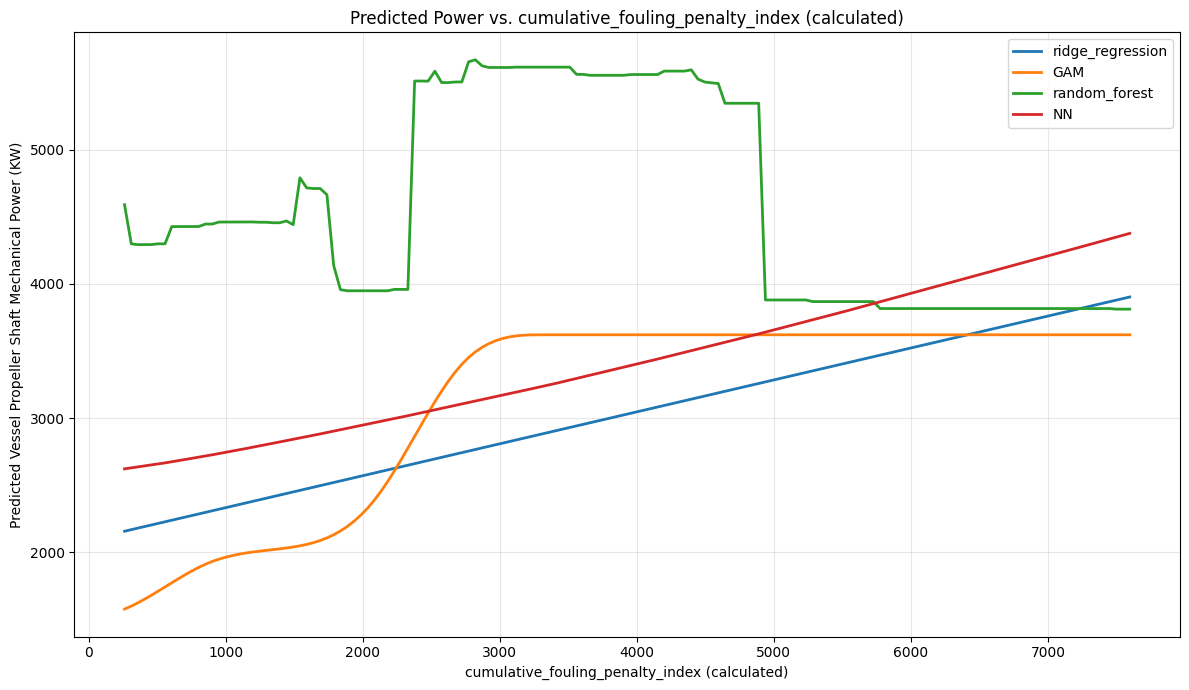

In [82]:
# Fouling only (all other features at median)
plot_controlled_var_predictions(fouling_only_path, model_pipelines_incl_foul)

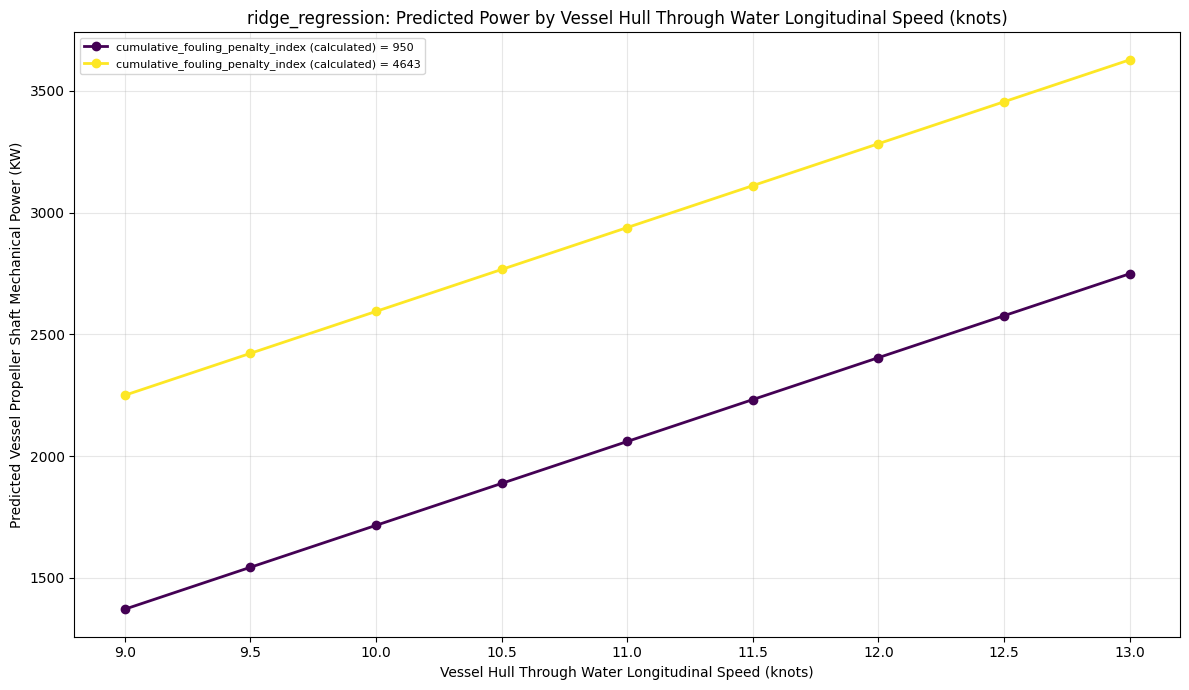

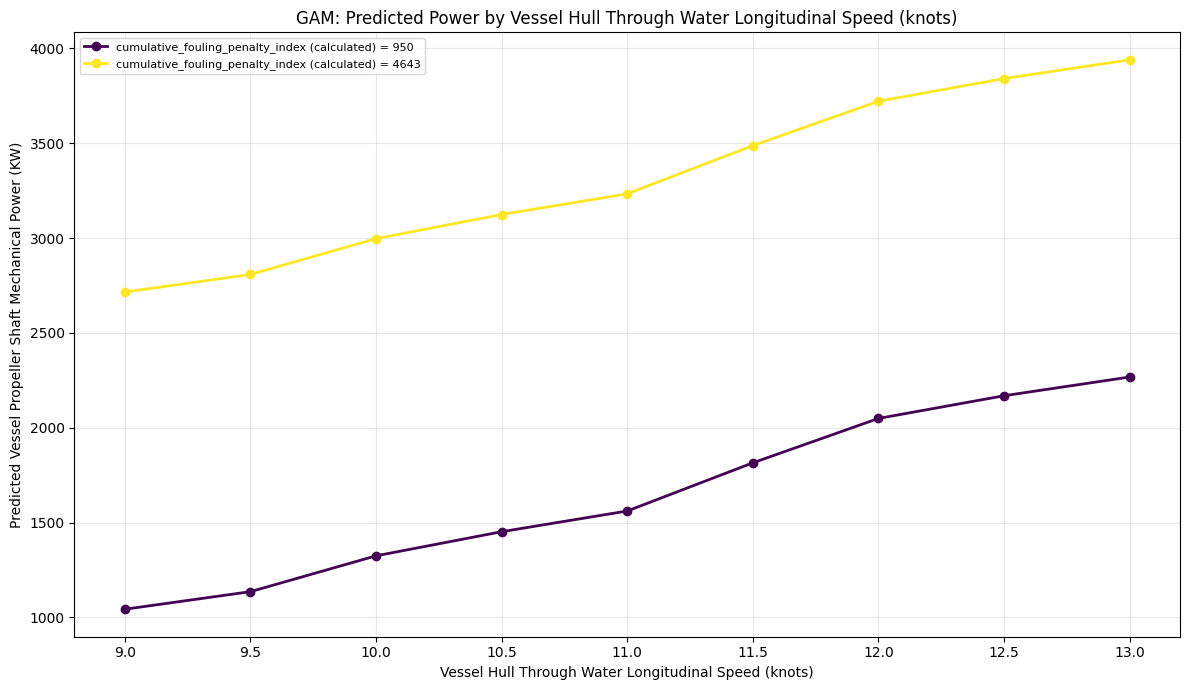

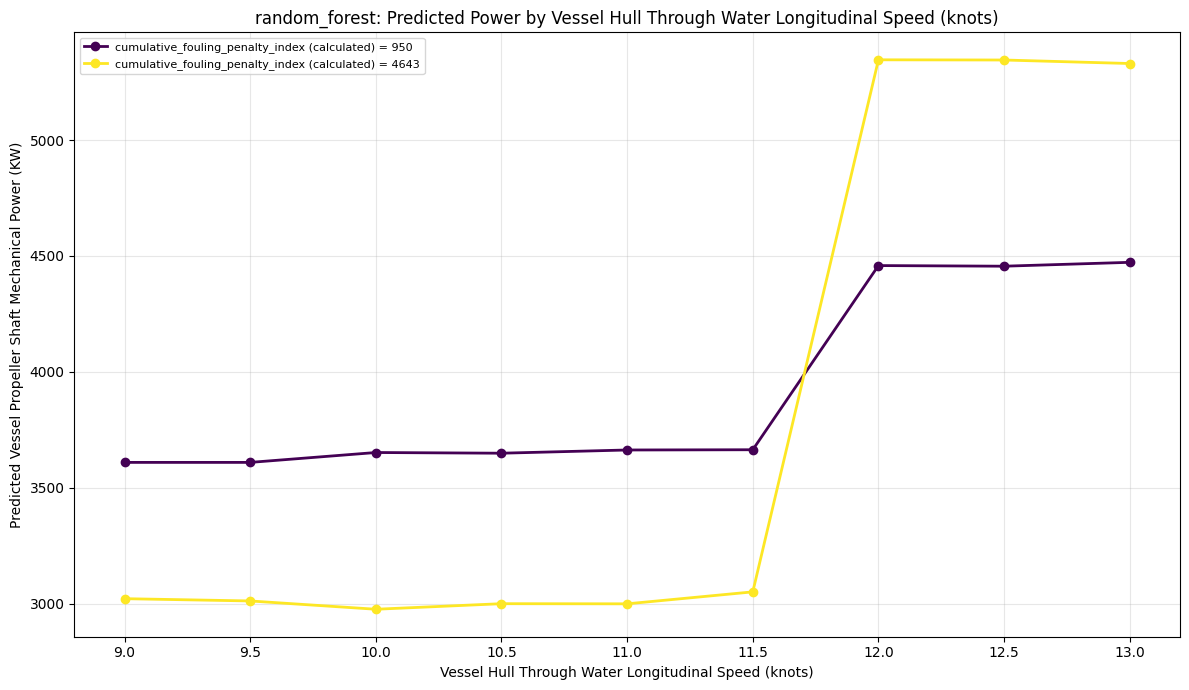

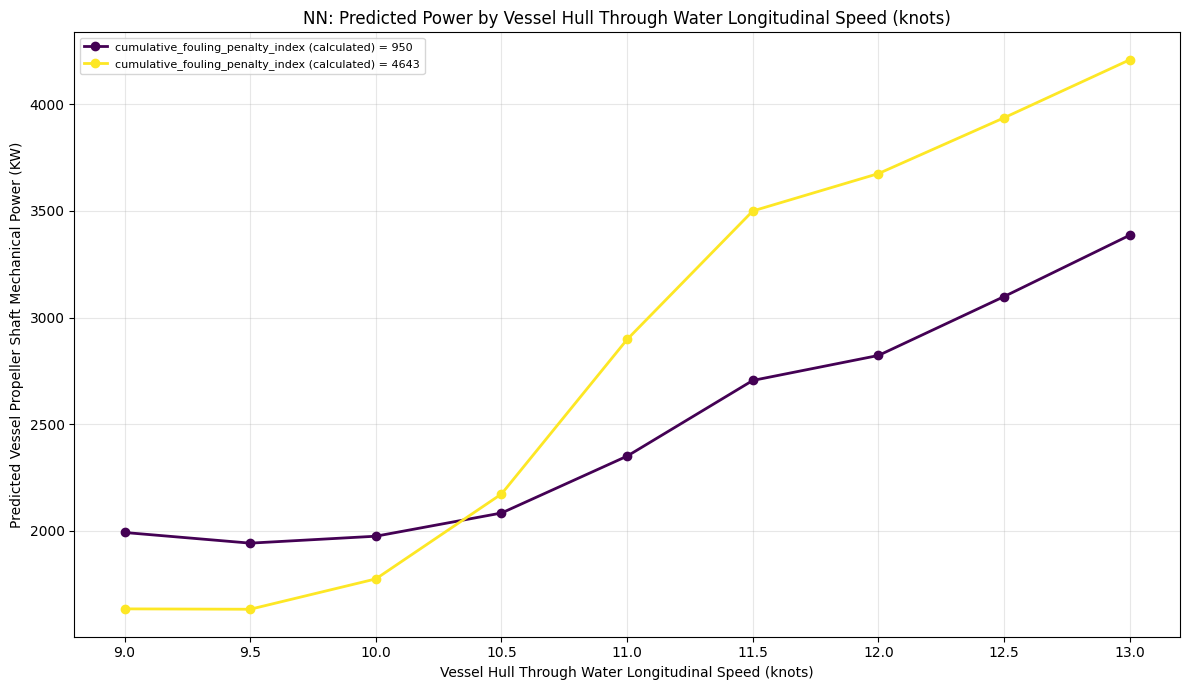

In [83]:
# Fouling × Speed — one plot per model, lines at fouling quantiles
plot_controlled_var_predictions(
    fouling_speed_path,
    model_pipelines_incl_foul,
    second_controlled_var_name=SPEED_VARIABLE,
    second_controlled_var_values=[9, 9.5, 10, 10.5, 11, 11.5, 12, 12.5, 13],
    fouling_quantiles=[0.1,0.6],
)

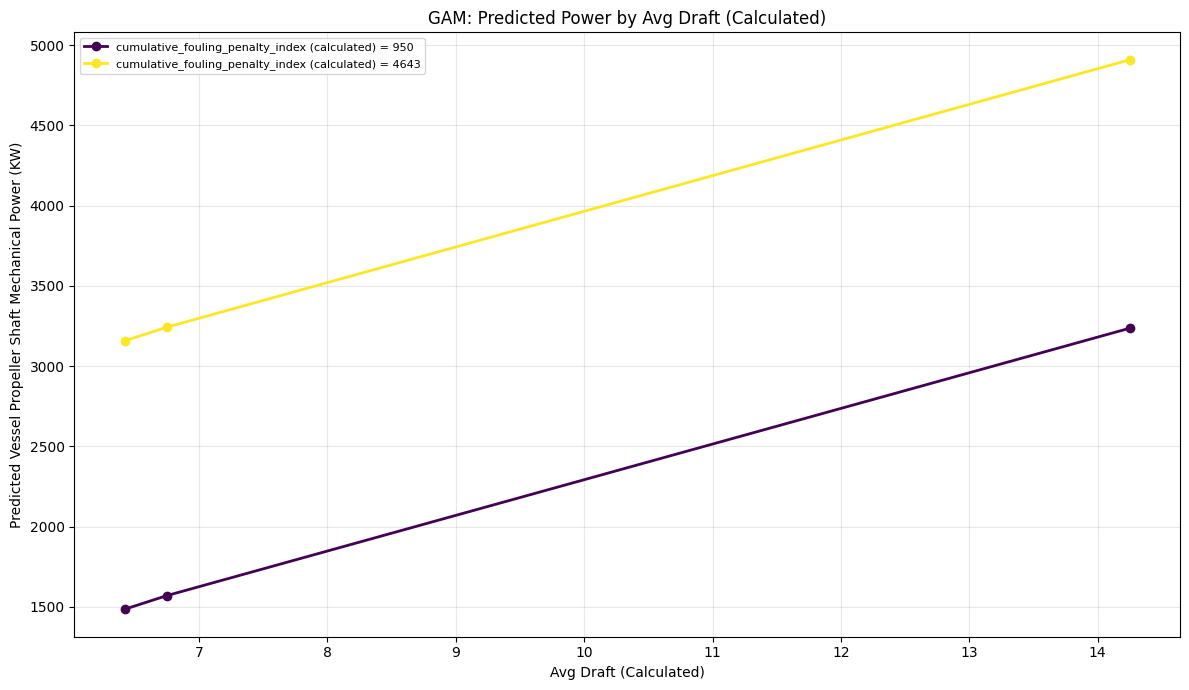

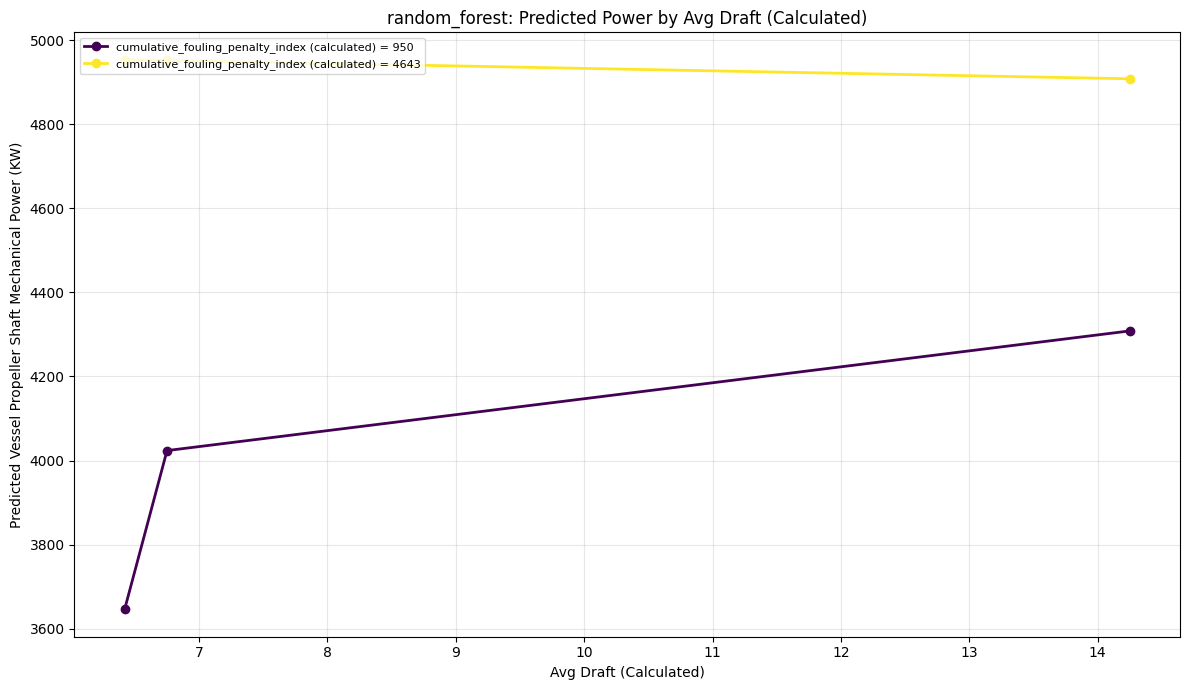

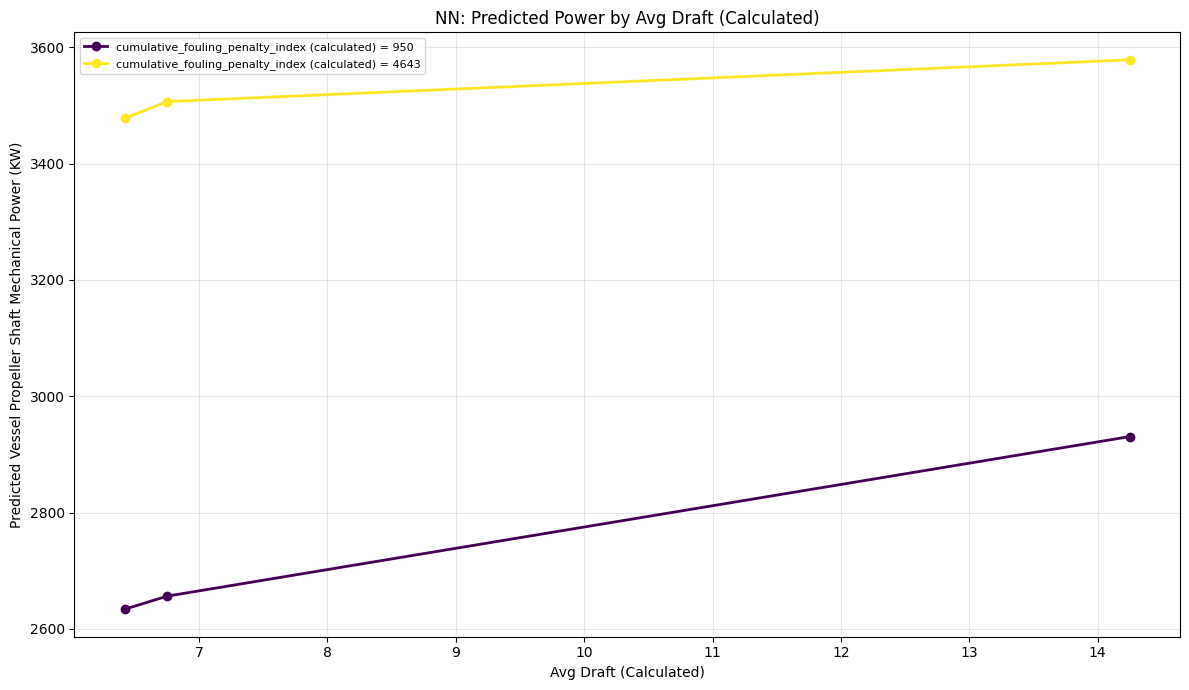

In [84]:
# Fouling × Draft — one plot per model, lines at fouling quantiles
drafts_to_test = [6.42, 6.75, 14.25]

plot_controlled_var_predictions(
    fouling_draft_path,
    pipelines_excl_ridge,
    second_controlled_var_name="Avg Draft (Calculated)",
    second_controlled_var_values=drafts_to_test,
    fouling_quantiles=[0.1,0.6],
)

# 4. Sensitivity Analysis